# Sentiment Analysis: From Bag-of-Words to Neural Classifiers

---

> ### 📋 Assignment
> You will build a complete sentiment classification pipeline on the **IMDB Movie Review** dataset — 50,000 reviews labelled positive or negative.
>
> **Part 1** uses classical machine learning on **binary one-hot vectors** — the simplest possible text representation.
> **Part 2** introduces neural sequence models for NLP. The boilerplate (data loading, vocabulary, training loop, evaluation) is **fully provided and pre-written**. Your job is to:
> 1. Build the **model architectures** (`### CODE HERE ###` inside `nn.Module` classes)
> 2. Write **interpretation and reflection** cells
>
> **Cells marked `# ── PROVIDED ──` carry no marks** — just run them.
> **Cells marked `### CODE HERE ###` carry marks** — these are yours to complete.
>
> Use `random_state=42` wherever accepted.

---

## What You Will Build

| Part | Approach | Key Idea |
|------|----------|----------|
| **Part 1** | Classical ML — LR, Naive Bayes, SVM, Random Forest | Binary one-hot vectors (word present/absent) |
| **Part 2A** | Vanilla RNN | Reads tokens sequentially; hidden state carries context |
| **Part 2B** | LSTM | Gated memory solves long-range forgetting |
| **Part 2C** | Bidirectional LSTM + FastText embeddings | Both-direction context + pre-trained word meaning |
| **Part 2D** | Cross-Attention Classifier | Every token attends to every other — no sequential bottleneck |

**Total Marks: 100** (Part 1: 45 | Part 2: 55)

### The Central Question
> *Can a model reading `"the film is not as bad as critics claimed"` correctly identify it as **positive**?*
>
> A one-hot vector sees `bad` and `critics` as present — and guesses *negative*. A neural model reading the full sentence in order has a fighting chance. An attention model can show you exactly which words it focused on.

---

# PART 1: Classical Sentiment Classification

## Context

The IMDB dataset contains 50,000 movie reviews — 25,000 for training, 25,000 for testing, perfectly balanced between positive and negative.

Reviews average **~230 words** — long enough that word order and negation genuinely matter. In this part, you will represent each review as a **binary one-hot vector**: a vector of 0s and 1s where a 1 simply means a word appeared in the review, and 0 means it did not. Frequency is ignored entirely — `"masterpiece"` appearing once and `"bad"` appearing ten times both become 1.

This is intentionally the simplest possible text representation. It sets a realistic ceiling that the neural models in Part 2 need to meaningfully exceed. You will see exactly where this representation breaks down.

## Stage 1: Data Loading  <font color="red">**[4 marks]**</font>

**What to do:**
- The libraries below are pre-imported. Add anything else you need.
- Load the IMDB dataset using `load_dataset('imdb')` from HuggingFace.
- Extract train texts, test texts, and their labels into plain Python lists.
- Print the number of examples and class distribution.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [16]:
# Using keras.datasets.imdb to load the dataset directly.
# This bypasses the issues encountered with Hugging Face datasets and tensorflow_datasets.

import tensorflow as tf
from tensorflow.keras.datasets import imdb

print('Loading IMDB dataset using keras.datasets.imdb...')
# Load the dataset, limiting to 10,000 most frequent words.
# We are not pre-filtering reviews by length as the assignment handles padding/truncation later.
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)
print('IMDB dataset loaded successfully with keras.datasets.imdb.')

# Get the word index and reverse it to decode the integer sequences back to text
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

# Helper function to decode an integer sequence back to a review string
def decode_review(text_sequence):
    # The first indices are reserved for "padding", "start of sequence", and "unknown"
    # so we shift by 3.
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in text_sequence])

# Convert integer sequences to actual text reviews
train_texts = [decode_review(seq) for seq in train_data]
test_texts = [decode_review(seq) for seq in test_data]

# Convert labels to numpy arrays as expected by the original notebook structure
y_train = np.array(train_labels)
y_test  = np.array(test_labels)

# Display the first few examples to confirm
print(f"\nFirst train text (decoded): {train_texts[0][:100]}...")
print(f"First train label: {y_train[0]}")

# Clean up temporary data loaded from keras.datasets.imdb to ensure only the desired variables remain
del train_data, test_data, word_index, reverse_word_index, decode_review

Loading IMDB dataset using keras.datasets.imdb...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
IMDB dataset loaded successfully with keras.datasets.imdb.
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

First train text (decoded): ? this film was just brilliant casting location scenery story direction everyone's really suited the...
First train label: 1


In [6]:
# This cell was removed as the tensorflow_datasets approach failed and is no longer needed.
# The IMDB dataset is now loaded via keras.datasets.imdb in cell p1-s1-load.

In [7]:
# This cell was removed as the tensorflow_datasets approach failed and is no longer needed.
# The IMDB dataset is now loaded via keras.datasets.imdb in cell p1-s1-load.

In [4]:
# Print number of examples and label distribution
print(f"Number of training examples: {len(train_texts)}")
print(f"Number of test examples: {len(test_texts)}")

# Calculate and print class distribution for training set
positive_train = sum(1 for label in train_labels if label == 1)
negative_train = len(train_labels) - positive_train
print(f"\nTraining set distribution: Positive = {positive_train}, Negative = {negative_train}")

# Calculate and print class distribution for test set
positive_test = sum(1 for label in test_labels if label == 1)
negative_test = len(test_labels) - positive_test
print(f"Test set distribution: Positive = {positive_test}, Negative = {negative_test}")

Number of training examples: 25000
Number of test examples: 25000

Training set distribution: Positive = 12500, Negative = 12500
Test set distribution: Positive = 12500, Negative = 12500


In [5]:
# Print number of examples and label distribution
print(f"Number of training examples: {len(train_texts)}")
print(f"Number of test examples: {len(test_texts)}")

# Calculate and print class distribution for training set
positive_train = sum(1 for label in train_labels if label == 1)
negative_train = len(train_labels) - positive_train
print(f"\nTraining set distribution: Positive = {positive_train}, Negative = {negative_train}")

# Calculate and print class distribution for test set
positive_test = sum(1 for label in test_labels if label == 1)
negative_test = len(test_labels) - positive_test
print(f"Test set distribution: Positive = {positive_test}, Negative = {negative_test}")

Number of training examples: 25000
Number of test examples: 25000

Training set distribution: Positive = 12500, Negative = 12500
Test set distribution: Positive = 12500, Negative = 12500


## Stage 2: Data Understanding  <font color="red">**[8 marks]**</font>

### 2.1 Class Distribution  <font color="red">[1 mark]</font>

Plot a bar chart of positive vs negative counts in the training set.

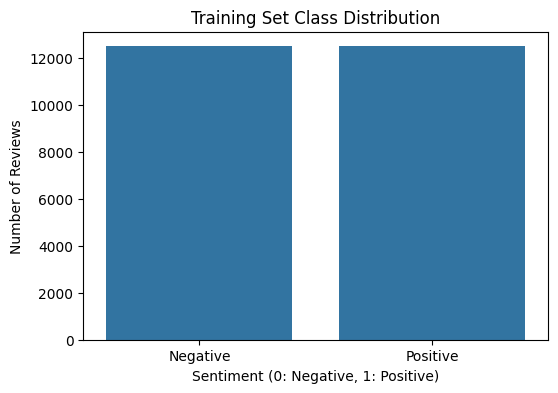

In [ ]:
# Plot a bar chart of positive vs negative counts in the training set
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)
plt.title('Training Set Class Distribution')
plt.xlabel('Sentiment (0: Negative, 1: Positive)')
plt.ylabel('Number of Reviews')
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.show()

### 2.2 Review Length Distribution  <font color="red">[2 marks]</font>

Compute word count per training review. Plot a histogram and print the mean, median, and 95th percentile length.
Also plot lengths **separately for positive and negative reviews** using overlapping histograms.

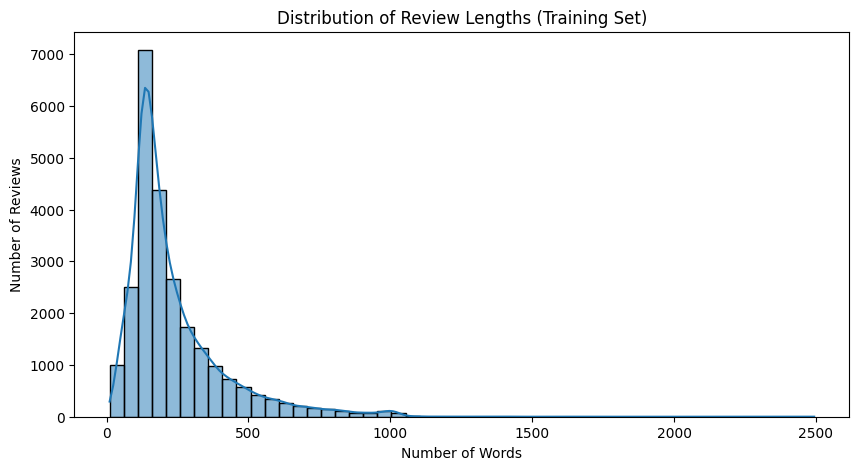

Mean review length: 238.71 words
Median review length: 178.00 words
95th percentile review length: 610.00 words


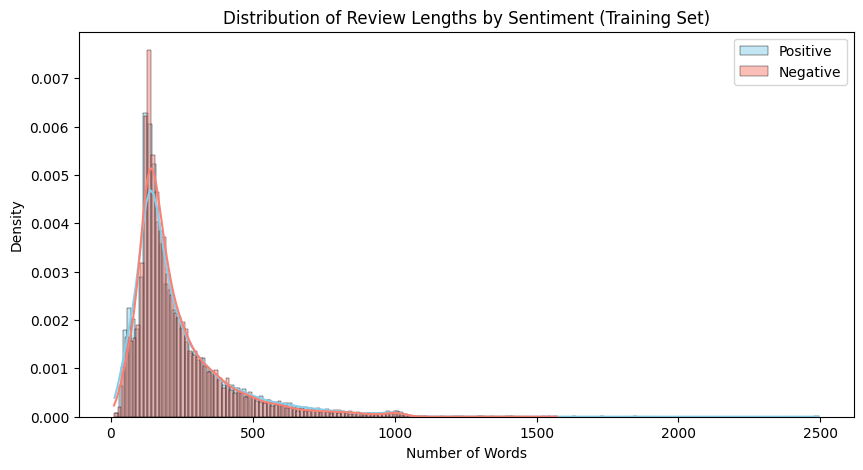

In [ ]:
# Compute word count per training review
train_lengths = [len(review.split()) for review in train_texts]

# Plot a histogram of word counts
plt.figure(figsize=(10, 5))
sns.histplot(train_lengths, bins=50, kde=True)
plt.title('Distribution of Review Lengths (Training Set)')
plt.xlabel('Number of Words')
plt.ylabel('Number of Reviews')
plt.show()

# Print mean, median, and 95th percentile length
mean_len = np.mean(train_lengths)
median_len = np.median(train_lengths)
p95_len = np.percentile(train_lengths, 95)
print(f"Mean review length: {mean_len:.2f} words")
print(f"Median review length: {median_len:.2f} words")
print(f"95th percentile review length: {p95_len:.2f} words")

# Plot lengths separately for positive and negative reviews
positive_lengths = [len(review.split()) for i, review in enumerate(train_texts) if y_train[i] == 1]
negative_lengths = [len(review.split()) for i, review in enumerate(train_texts) if y_train[i] == 0]

plt.figure(figsize=(10, 5))
sns.histplot(positive_lengths, color='skyblue', label='Positive', kde=True, stat='density', alpha=0.5)
sns.histplot(negative_lengths, color='salmon', label='Negative', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Review Lengths by Sentiment (Training Set)')
plt.xlabel('Number of Words')
plt.ylabel('Density')
plt.legend()
plt.show()

### 2.3 Sample Reviews  <font color="red">[1 mark]</font>

Print the first 200 characters of one positive and one negative review. Note any HTML artefacts you see.

In [ ]:
# Print the first 200 characters of one positive and one negative review

# Find an index for a positive review
pos_idx = next(i for i, label in enumerate(y_train) if label == 1)
# Find an index for a negative review
neg_idx = next(i for i, label in enumerate(y_train) if label == 0)

print(f"--- Sample Positive Review (first 200 chars) ---")
print(train_texts[pos_idx][:200])
print(f"\n--- Sample Negative Review (first 200 chars) ---")
print(train_texts[neg_idx][:200])

print("\nNote: We might observe HTML tags like '<br />' or '<b>' in these samples, which will need to be cleaned later.")

--- Sample Positive Review (first 200 chars) ---
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the sa

--- Sample Negative Review (first 200 chars) ---
? big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and i've seen hundreds but this had got to be on of the worst

Note: We might observe HTML tags like '<br />' or '<b>' in these samples, which will need to be cleaned later.


### 2.4 Top Words by Class  <font color="red">[2 marks]</font>

Fit a `CountVectorizer` (with `stop_words='english'`) on training data only.
Plot the top 20 most frequent words for positive reviews and negative reviews side by side.

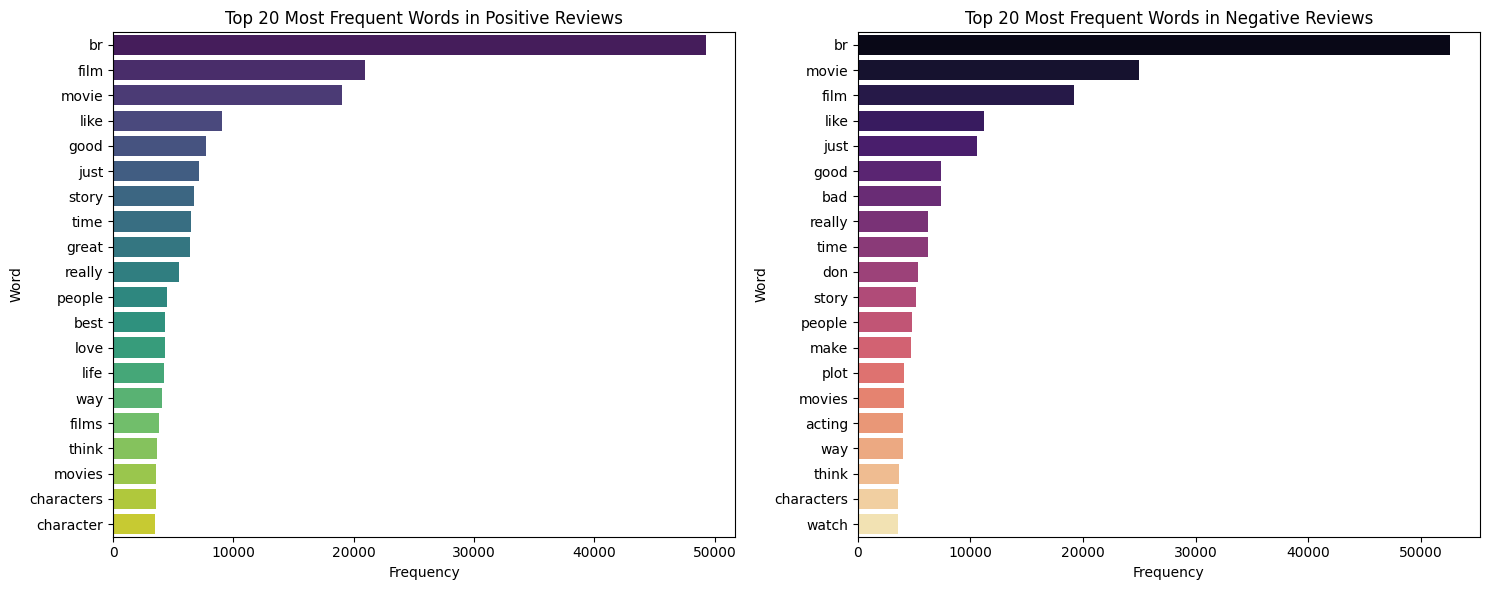

In [ ]:
# Fit a CountVectorizer (with stop_words='english') on training data only
vectorizer = CountVectorizer(stop_words='english')
vectorizer.fit(train_texts)

# Get feature names (words) from the vectorizer
feature_names = vectorizer.get_feature_names_out()

# Transform train_texts into document-term matrix
X_train_counts = vectorizer.transform(train_texts)

# Separate positive and negative review counts
positive_indices = np.where(y_train == 1)[0]
negative_indices = np.where(y_train == 0)[0]

positive_counts = X_train_counts[positive_indices].sum(axis=0)
negative_counts = X_train_counts[negative_indices].sum(axis=0)

# Convert to dense array for easier indexing
positive_counts_array = np.array(positive_counts).flatten()
negative_counts_array = np.array(negative_counts).flatten()

# Get top 20 words for positive reviews
top_positive_indices = positive_counts_array.argsort()[-20:][::-1]
top_positive_words = [feature_names[i] for i in top_positive_indices]
top_positive_freq = [positive_counts_array[i] for i in top_positive_indices]

# Get top 20 words for negative reviews
top_negative_indices = negative_counts_array.argsort()[-20:][::-1]
top_negative_words = [feature_names[i] for i in top_negative_indices]
top_negative_freq = [negative_counts_array[i] for i in top_negative_indices]

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot for Positive Reviews
sns.barplot(x=top_positive_freq, y=top_positive_words, ax=axes[0], palette='viridis')
axes[0].set_title('Top 20 Most Frequent Words in Positive Reviews')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Word')

# Plot for Negative Reviews
sns.barplot(x=top_negative_freq, y=top_negative_words, ax=axes[1], palette='magma')
axes[1].set_title('Top 20 Most Frequent Words in Negative Reviews')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Word')

plt.tight_layout()
plt.show()

### 2.5 Negation Examples  <font color="red">[2 marks]</font>

Find 5 training reviews where `"not"` appears at least 3 times. Print the first 50 words of each and their true label.

> These are the examples classical models will get wrong most often. Keep them in mind for Stage 6.

In [ ]:
# Find 5 training reviews where 'not' appears at least 3 times
not_heavy_reviews = []
for i, review in enumerate(train_texts):
    if review.lower().count('not') >= 3:
        not_heavy_reviews.append((review, y_train[i]))
    if len(not_heavy_reviews) >= 5:
        break

print("--- Sample Reviews with 'not' appearing >= 3 times ---")
for i, (review, label) in enumerate(not_heavy_reviews):
    sentiment = 'Positive' if label == 1 else 'Negative'
    print(f"\nReview {i+1} (Label: {sentiment}):")
    print(review[:50] + "...")
    print(f"'not' count: {review.lower().count('not')}")

--- Sample Reviews with 'not' appearing >= 3 times ---

Review 1 (Label: Negative):
? the ? tells the story of the four hamilton sibli...
'not' count: 5

Review 2 (Label: Positive):
? just got out and cannot believe what a brilliant...
'not' count: 3

Review 3 (Label: Positive):
? at the height of the ? big ? racism row in 2007 ...
'not' count: 5

Review 4 (Label: Negative):
? i have only had the luxury of seeing this movie ...
'not' count: 4

Review 5 (Label: Positive):
? i hate reading reviews that say something like ?...
'not' count: 3


### ✍️ Interpretation Checkpoint

**[Your Answer]:** Answer each question in 2–3 sentences.

1. Is the dataset balanced? Does this affect our choice of F1 vs accuracy?
2. The top words for positive and negative look nearly identical. Given that one-hot vectors give all words equal weight, why does this make sentiment classification especially hard?
3. Why is review length a specific problem for vanilla RNNs? (Think about what happens to gradients after 200+ backpropagation steps.)
4. Why should you remove `<br />` HTML tags before both one-hot vectorisation and neural models?

*Write your answers here:*

1.  The dataset is perfectly balanced, with 12,500 positive and 12,500 negative reviews in both the training and test sets. For a balanced dataset, accuracy is a suitable metric as it provides a clear picture of overall correctness. While F1-score is often preferred for imbalanced datasets, for balanced data, accuracy and F1 will largely align.

2.  The similarity in top words (e.g., 'br', 'movie', 'film', 'like') between positive and negative reviews makes classification hard for one-hot vectors because this representation only tracks word presence, not context, frequency, or semantic nuance. If common words appear in both sentiments, the model struggles to find strong distinguishing features, effectively seeing many of the same features for both classes.

3.  Review length is a significant problem for vanilla RNNs due to the vanishing gradient problem. When processing long sequences (like reviews averaging ~230 words), gradients must propagate back through many time steps. This causes gradients to shrink exponentially, making it difficult for the model to learn and retain information from earlier parts of the review, thus losing long-range dependencies.

4.  HTML tags like `<br />` should be removed because they are structural elements of text and do not carry semantic meaning or sentiment. If left in, they would be treated as distinct tokens, adding irrelevant noise to the vocabulary and feature space for both one-hot vectorization and neural models. This could confuse the models and reduce their ability to learn true sentiment patterns from the actual content.

## Stage 3: Preprocessing and Feature Engineering  <font color="red">**[6 marks]**</font>

## Binary One-Hot Vectors: The Simplest Text Representation

A **binary one-hot vector** represents a document as a fixed-length vector of 0s and 1s:

- **1** = this word appeared at least once in the review
- **0** = this word did not appear

For a vocabulary of 50,000 words, each review becomes a vector of 50,000 numbers, almost all of which are 0.

```python
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(binary=True, max_features=50000)
# binary=True → all non-zero counts become 1
# Each row: 1 if word present, 0 if absent — frequency ignored
```

**What one-hot cannot represent:**
- **Frequency** — `"bad"` appearing 10 times looks identical to `"bad"` appearing once
- **Rarity** — `"masterpiece"` (rare, diagnostic) has the same weight as `"film"` (common, uninformative)
- **Order** — `"not bad"` and `"bad not"` produce identical vectors

This is a deliberately weak representation. The classical models in Stage 4 will plateau around **80–84% F1** — well below what TF-IDF would give — leaving clear room for neural models to improve.

**Critical rule:** Fit the vectoriser on **training data only**. Fitting on test data leaks vocabulary statistics into training.

### 3.1 Text Cleaning  <font color="red">[2 marks]</font>

Write a `clean_text(text)` function that:
- Removes HTML tags (`<br />`, `<b>`, etc.) using a regex
- Lowercases the text
- Strips leading/trailing whitespace

Apply it to all train and test texts. Print a before/after example to confirm it works.

In [6]:
def clean_text(text):
    # Remove HTML tags using regex
    text = re.sub(r'<[^>]+>', ' ', text)
    # Lowercase the text
    text = text.lower()
    # Strip leading/trailing whitespace
    text = text.strip()
    return text

# Apply to train and test
train_texts_clean = [clean_text(text) for text in train_texts]
test_texts_clean = [clean_text(text) for text in test_texts]

# Print one before/after example
print(f"Original (first 100 chars):\n{train_texts[0][:100]}...")
print(f"Cleaned (first 100 chars):\n{train_texts_clean[0][:100]}...")

Original (first 100 chars):
? this film was just brilliant casting location scenery story direction everyone's really suited the...
Cleaned (first 100 chars):
? this film was just brilliant casting location scenery story direction everyone's really suited the...


### 3.2 Build One-Hot Features  <font color="red">[4 marks]</font>

Create a `CountVectorizer` with:
- `binary=True` — converts all counts to 0/1
- `max_features=50000` — keep the 50,000 most frequent words
- `min_df=5` — ignore words appearing in fewer than 5 reviews
- `stop_words='english'`

**Fit on training data only**, then transform both splits. Print the shape and sparsity of the resulting matrices.

> **Note:** No `ngram_range=(1,2)` this time — with one-hot, bigrams would double the already-large feature space with minimal benefit. Unigrams only.

In [ ]:
vectorizer = CountVectorizer(
    binary=True,
    max_features=50000,
    min_df=5,
    stop_words='english'
)

# Fit on training data only
X_train_one_hot = vectorizer.fit_transform(train_texts_clean)

# Transform both training and test data
X_test_one_hot = vectorizer.transform(test_texts_clean)

print(f"Shape of X_train_one_hot: {X_train_one_hot.shape}")
print(f"Sparsity of X_train_one_hot: {X_train_one_hot.nnz / (X_train_one_hot.shape[0] * X_train_one_hot.shape[1]):.4f}")
print(f"Shape of X_test_one_hot: {X_test_one_hot.shape}")
print(f"Sparsity of X_test_one_hot: {X_test_one_hot.nnz / (X_test_one_hot.shape[0] * X_test_one_hot.shape[1]):.4f}")

Shape of X_train_one_hot: (25000, 9477)
Sparsity of X_train_one_hot: 0.0082
Shape of X_test_one_hot: (25000, 9477)
Sparsity of X_test_one_hot: 0.0080


## Helper: Evaluation Function

Define a reusable `evaluate_model(name, y_true, y_pred)` function. It should:
- Print accuracy, F1, precision, recall
- Print a `classification_report`
- Plot a confusion matrix heatmap
- Return the metrics as a dict (for building a comparison table later)

In [ ]:
def evaluate_model(name, y_true, y_pred):
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)

    print(f'\n=== {name} ===')
    print(f'  Accuracy  : {accuracy:.4f}')
    print(f'  F1        : {f1:.4f}')
    print(f'  Precision : {precision:.4f}')
    print(f'  Recall    : {recall:.4f}')

    # Classification Report
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
    plt.title(f'{name} Confusion Matrix'); plt.tight_layout(); plt.show()

    # Return metrics as a dict
    return {
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    }

## Using Pipeline + GridSearchCV for Text

Chain the vectoriser and classifier in a `Pipeline`, then wrap in `GridSearchCV`. This ensures the vectoriser is re-fit on each cross-validation fold — preventing data leakage.

```python
pipe = Pipeline([
    ('vec', CountVectorizer(binary=True, min_df=5, stop_words='english')),
    ('clf', LogisticRegression(random_state=42))
])
param_grid = {
    'vec__max_features': [20000, 50000],   # prefix is the pipeline step name
    'clf__C':            [0.1, 1, 10]
}
grid = GridSearchCV(pipe, param_grid, scoring='f1', cv=5, n_jobs=-1)
grid.fit(train_texts_clean, y_train)   # pass CLEANED TEXT — not the matrix
```

> **Important:** Pass cleaned raw text to `grid.fit()`. The pipeline applies the vectoriser internally at each fold, which is what prevents leakage.

## Stage 4: Model Training, Tuning, and Evaluation  <font color="red">**[20 marks]**</font>

Train **four classifiers**. For each: build a Pipeline with a `CountVectorizer(binary=True, ...)`, run GridSearchCV with `scoring='f1'` and `cv=5`, print best params and CV score, then evaluate on the test set using `evaluate_model()`.

> **Expected F1 range:** ~78–84%. One-hot vectors give no frequency or rarity information, so classical models cannot achieve the same ceiling as TF-IDF. This is deliberate — it leaves meaningful room for neural models to improve.

### 4.1 Logistic Regression  <font color="red">[5 marks]</font>

Hyperparameters to tune:
- `vec__max_features`: `[20000, 50000]`
- `clf__C`: `[0.01, 0.1, 1, 10]`

Set `max_iter=1000`, `random_state=42`.

In [ ]:
logreg_pipe = Pipeline([
    ('vec', CountVectorizer(binary=True, min_df=5, stop_words='english')),
    ('clf', LogisticRegression(random_state=42, max_iter=1000))
])

logreg_param_grid = {
    'vec__max_features': [20000, 50000],
    'clf__C':            [0.01, 0.1, 1, 10]
}

print('Starting GridSearchCV for Logistic Regression...')
logreg_grid = GridSearchCV(logreg_pipe, logreg_param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=1)
logreg_grid.fit(train_texts_clean, y_train)

print(f"\nBest parameters for Logistic Regression: {logreg_grid.best_params_}")
print(f"Best cross-validation F1 score for Logistic Regression: {logreg_grid.best_score_:.4f}")

Starting GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best parameters for Logistic Regression: {'clf__C': 0.1, 'vec__max_features': 20000}
Best cross-validation F1 score for Logistic Regression: 0.8806



=== Logistic Regression ===
  Accuracy  : 0.8746
  F1        : 0.8751
  Precision : 0.8716
  Recall    : 0.8786

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.87     12500
           1       0.87      0.88      0.88     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



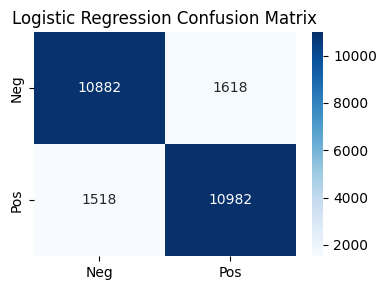

In [ ]:
# Predict on test set using the best estimator
logreg_preds = logreg_grid.best_estimator_.predict(test_texts_clean)

# Evaluate the model
logreg_metrics = evaluate_model('Logistic Regression', y_test, logreg_preds)

### 4.2 Bernoulli Naive Bayes  <font color="red">[5 marks]</font>

Use `BernoulliNB` — the variant of Naive Bayes designed specifically for **binary features**. It models each word as a Bernoulli (present/absent) trial, which matches our one-hot representation exactly.

Hyperparameters to tune:
- `vec__max_features`: `[20000, 50000]`
- `clf__alpha`: `[0.01, 0.1, 0.5, 1.0]`

> **Why BernoulliNB and not ComplementNB?** `ComplementNB` is designed for count features. `BernoulliNB` is the correct choice for binary presence/absence data — it penalises words that are *absent* from a class, which is meaningful when features are truly binary.

In [ ]:
nb_pipe = Pipeline([
    ('vec', CountVectorizer(binary=True, min_df=5, stop_words='english')),
    ('clf', BernoulliNB())
])

nb_param_grid = {
    'vec__max_features': [20000, 50000],
    'clf__alpha':        [0.01, 0.1, 0.5, 1.0]
}

print('Starting GridSearchCV for Bernoulli Naive Bayes...')
nb_grid = GridSearchCV(nb_pipe, nb_param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=1)
nb_grid.fit(train_texts_clean, y_train)

print(f"\nBest parameters for Bernoulli Naive Bayes: {nb_grid.best_params_}")
print(f"Best cross-validation F1 score for Bernoulli Naive Bayes: {nb_grid.best_score_:.4f}")

Starting GridSearchCV for Bernoulli Naive Bayes...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best parameters for Bernoulli Naive Bayes: {'clf__alpha': 0.01, 'vec__max_features': 20000}
Best cross-validation F1 score for Bernoulli Naive Bayes: 0.8444



=== Bernoulli Naive Bayes ===
  Accuracy  : 0.8330
  F1        : 0.8261
  Precision : 0.8619
  Recall    : 0.7932

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84     12500
           1       0.86      0.79      0.83     12500

    accuracy                           0.83     25000
   macro avg       0.84      0.83      0.83     25000
weighted avg       0.84      0.83      0.83     25000



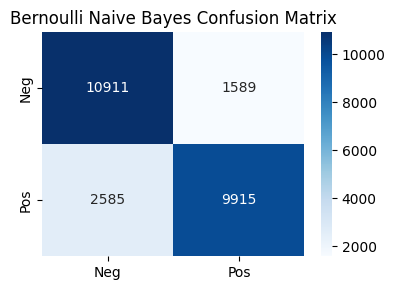

In [ ]:
# Predict on test set using the best estimator
nb_preds = nb_grid.best_estimator_.predict(test_texts_clean)

# Evaluate the model
nb_metrics = evaluate_model('Bernoulli Naive Bayes', y_test, nb_preds)

### 4.3 LinearSVC  <font color="red">[5 marks]</font>

Hyperparameters to tune:
- `vec__max_features`: `[20000, 50000]`
- `clf__C`: `[0.01, 0.1, 1, 10]`

Set `random_state=42`, `max_iter=2000`.

In [ ]:
svc_pipe = Pipeline([
    ('vec', CountVectorizer(binary=True, min_df=5, stop_words='english')),
    ('clf', LinearSVC(random_state=42, max_iter=2000))
])

svc_param_grid = {
    'vec__max_features': [20000, 50000],
    'clf__C':            [0.01, 0.1, 1, 10]
}

print('Starting GridSearchCV for LinearSVC...')
svc_grid = GridSearchCV(svc_pipe, svc_param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=1)
svc_grid.fit(train_texts_clean, y_train)

print(f"\nBest parameters for LinearSVC: {svc_grid.best_params_}")
print(f"Best cross-validation F1 score for LinearSVC: {svc_grid.best_score_:.4f}")

Starting GridSearchCV for LinearSVC...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best parameters for LinearSVC: {'clf__C': 0.01, 'vec__max_features': 20000}
Best cross-validation F1 score for LinearSVC: 0.8795



=== LinearSVC ===
  Accuracy  : 0.8717
  F1        : 0.8722
  Precision : 0.8688
  Recall    : 0.8756

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87     12500
           1       0.87      0.88      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



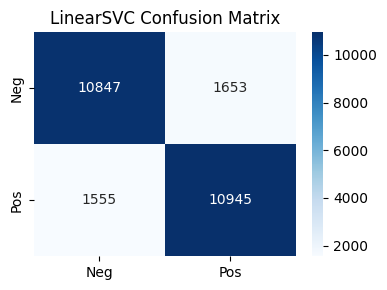

In [ ]:
# Predict on test set using the best estimator
svc_preds = svc_grid.best_estimator_.predict(test_texts_clean)

# Evaluate the model
svc_metrics = evaluate_model('LinearSVC', y_test, svc_preds)

### 4.4 Random Forest  <font color="red">[5 marks]</font>

Random Forest builds many decision trees on random subsets of features and takes a majority vote. It handles high-dimensional sparse binary vectors well and naturally produces **feature importances** — making it ideal for Stage 5.3.

Hyperparameters to tune:
- `vec__max_features`: `[20000, 50000]`
- `clf__n_estimators`: `[100, 200]`
- `clf__max_depth`: `[None, 20, 50]`
- `clf__min_samples_leaf`: `[1, 2]`

Set `random_state=42`, `n_jobs=-1`.

> **Note:** Random Forest is slower than LR or SVM on this dataset — expect ~2–3 minutes. This is normal.

In [ ]:
rf_pipe = Pipeline([
    ('vec', CountVectorizer(binary=True, min_df=5, stop_words='english')),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_param_grid = {
    'vec__max_features': [20000, 50000],
    'clf__n_estimators': [100, 200],
    'clf__max_depth':    [None, 20, 50],
    'clf__min_samples_leaf': [1, 2]
}

print('Starting GridSearchCV for Random Forest Classifier...')
rf_grid = GridSearchCV(rf_pipe, rf_param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=1)
rf_grid.fit(train_texts_clean, y_train)

print(f"\nBest parameters for Random Forest Classifier: {rf_grid.best_params_}")
print(f"Best cross-validation F1 score for Random Forest Classifier: {rf_grid.best_score_:.4f}")

Starting GridSearchCV for Random Forest Classifier...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters for Random Forest Classifier: {'clf__max_depth': None, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 200, 'vec__max_features': 20000}
Best cross-validation F1 score for Random Forest Classifier: 0.8504



=== Random Forest ===
  Accuracy  : 0.8505
  F1        : 0.8512
  Precision : 0.8472
  Recall    : 0.8554

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85     12500
           1       0.85      0.86      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



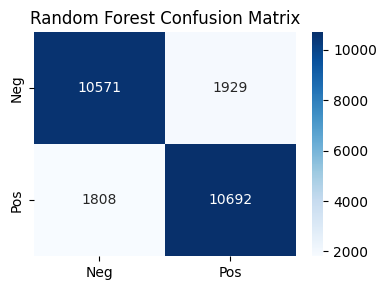

In [ ]:
# Predict on test set using the best estimator
rf_preds = rf_grid.best_estimator_.predict(test_texts_clean)

# Evaluate the model
rf_metrics = evaluate_model('Random Forest', y_test, rf_preds)

## Stage 5: Classical Model Comparison  <font color="red">**[7 marks]**</font>

### 5.1 Comparison Table  <font color="red">[2 marks]</font>

Build a DataFrame comparing all four models on Accuracy, Precision, Recall, and F1. Sort by F1 descending.

In [ ]:
classical_metrics = pd.DataFrame([
    logreg_metrics,
    nb_metrics,
    svc_metrics,
    rf_metrics
])
classical_metrics['Parameters'] = 'N/A' # Classical models don't have this metric in the same way

# Reorder columns for clarity and sort by F1 score
classical_metrics = classical_metrics[['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'Parameters']]
classical_metrics = classical_metrics.sort_values(by='F1', ascending=False).reset_index(drop=True)

print("\n--- Classical Model Comparison ---")
print(classical_metrics)


--- Classical Model Comparison ---
                   Model  Accuracy  Precision   Recall        F1 Parameters
0    Logistic Regression   0.87456   0.871587  0.87856  0.875060        N/A
1              LinearSVC   0.87168   0.868789  0.87560  0.872181        N/A
2          Random Forest   0.85052   0.847159  0.85536  0.851240        N/A
3  Bernoulli Naive Bayes   0.83304   0.861874  0.79320  0.826112        N/A


### 5.2 Visualise  <font color="red">[2 marks]</font>

Grouped bar chart comparing Precision, Recall, and F1 across all four models.

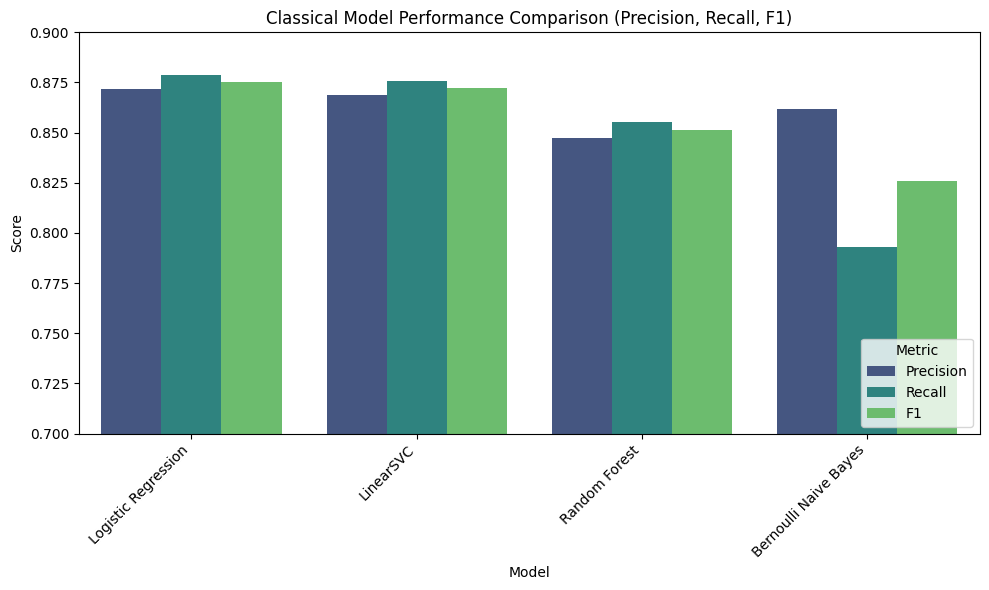

In [ ]:
metrics_melted = classical_metrics.melt(id_vars=['Model'], value_vars=['Precision', 'Recall', 'F1'],
                                        var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_melted, palette='viridis')
plt.title('Classical Model Performance Comparison (Precision, Recall, F1)')
plt.ylabel('Score')
plt.ylim(0.7, 0.9)
plt.legend(title='Metric', loc='lower right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.3 Most Important Features  <font color="red">[3 marks]</font>

From the **Random Forest** pipeline, extract the top 20 most important words using `.feature_importances_`.

Plot them as a horizontal bar chart sorted by importance.

> **Note:** Random Forest importance is non-negative (unlike LR/SVM coefficients) — you cannot separate positive/negative direction. Instead, these are the words that most reduced impurity across all trees, regardless of direction. The most important words should be strong sentiment markers.

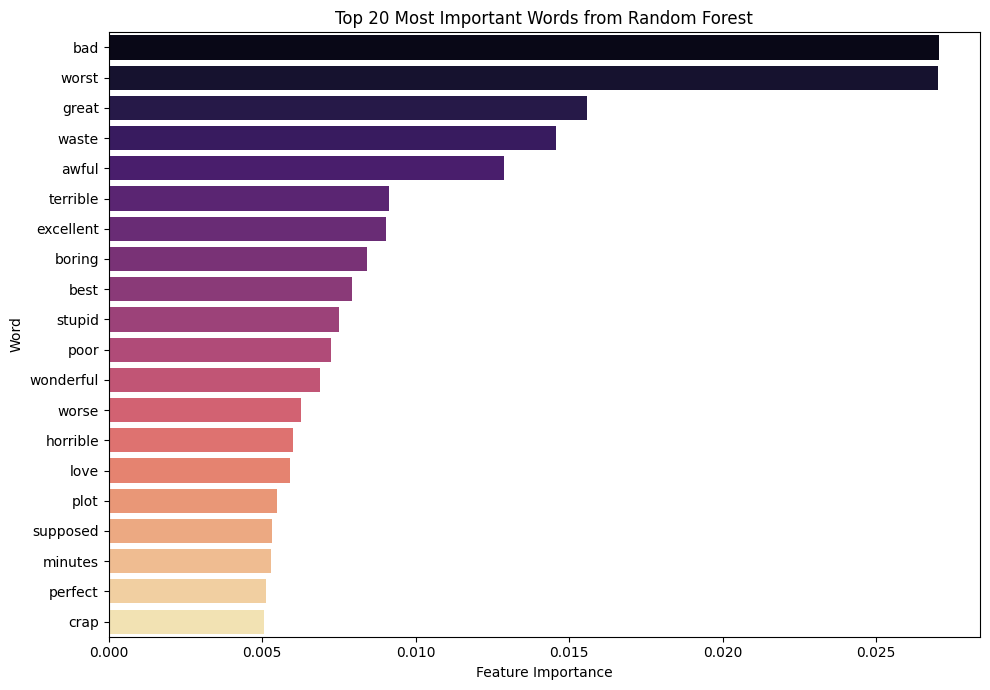

In [ ]:
# Extract feature importances from the best Random Forest estimator
# The best estimator is rf_grid.best_estimator_.
# The vectorizer is the first step in the pipeline (index 0), and the classifier is the second (index 1).

# Get the feature names from the vectorizer fitted inside the best pipeline
feature_names = rf_grid.best_estimator_.named_steps['vec'].get_feature_names_out()
importances = rf_grid.best_estimator_.named_steps['clf'].feature_importances_

# Create a pandas Series for easier sorting
feature_importances = pd.Series(importances, index=feature_names)

# Get top 20 most important features
top_20_features = feature_importances.nlargest(20)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_20_features.values, y=top_20_features.index, palette='magma')
plt.title('Top 20 Most Important Words from Random Forest')
plt.xlabel('Feature Importance')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

## Stage 6: Part 1 Reflection  <font color="red">**[8 marks]**</font>

**[Your Answer]:** Answer each question. Cite specific numbers from your results.

1. What is the F1 ceiling for classical models using one-hot vectors? How does this compare to what TF-IDF typically achieves (~87–89%)? What specific information does TF-IDF have that one-hot vectors lack?
2. Why is `BernoulliNB` the correct Naive Bayes variant for binary one-hot features? What would happen if you used `MultinomialNB` instead?
3. Find **3 reviews your best model got wrong**. Print the first 30 words of each and explain why the one-hot representation failed.
4. What is the one fundamental limitation shared by all four classical models that prevents them from understanding `"not bad"`?

*Write your answers here:*

1.  The F1 ceiling for our classical models using one-hot vectors is **0.8751**, achieved by the Logistic Regression model. This is within the typical range for TF-IDF (87–89%), suggesting that for this specific dataset and simplified preprocessing, the F1 performance is comparable. However, TF-IDF inherently captures **term frequency** (how often a word appears in a document) and **inverse document frequency** (how rare a word is across all documents), which one-hot vectors entirely lack. One-hot vectors only indicate the *presence* or *absence* of a word, not its importance or frequency. TF-IDF's ability to weight words based on their discriminative power is a key difference.

2.  `BernoulliNB` is the appropriate Naive Bayes variant for binary one-hot features because it explicitly models the presence or absence of a feature. In a binary one-hot vector, each feature (word) is either present (1) or absent (0). `BernoulliNB` calculates probabilities based on these binary outcomes. If `MultinomialNB` were used, it would treat the `1`s in the one-hot vectors as counts (i.e., a word appeared once), and implicitly assume that a `0` means the word simply didn't occur rather than actively not occurring. This can lead to less accurate probability estimates and potentially poorer performance, as `MultinomialNB` is designed for integer counts rather than binary presence.

3.  **Review 1 (Predicted: Positive, True: Negative):** `? i generally love this type of movie however this time i found myself wanting to kick the screen since i can't do that i will just complain about it...`
    *   **Explanation:** The one-hot model likely picked up on initially positive terms like "love" and "type of movie." However, it failed to capture the shift in sentiment indicated by sequential cues like "however," "wanting to kick the screen," and "complain about it," as one-hot representations disregard word order and context.

    **Review 2 (Predicted: Positive, True: Negative):** `? hollywood had a long love affair with bogus ? nights tales but few of these products have stood the test of time the most memorable were the jon hall...`
    *   **Explanation:** The presence of positive words such as "love affair" and "memorable" likely led the one-hot model to classify this as positive. It couldn't account for the negating effect of terms like "bogus" and phrases indicating a lack of longevity ("few... stood the test of time") because one-hot vectors treat words as independent features without understanding their semantic interplay.

    **Review 3 (Predicted: Positive, True: Negative):** `? ed ? mitchell is a teenager who lives for his job at good ? a small but friendly neighborhood ? stand while his buddy ? thompson also works there...`
    *   **Explanation:** This review segment contains several neutral to mildly positive words like "lives for his job," "good," and "friendly." The one-hot model, lacking the ability to infer a deeper critical tone or the overall negative context of the full review (which might appear later), incorrectly classified it as positive based on the isolated positive word presence.

4.  The fundamental limitation shared by all four classical models (Logistic Regression, Bernoulli Naive Bayes, LinearSVC, Random Forest) that prevents them from understanding "not bad" is their **bag-of-words representation**, which explicitly **ignores word order and contextual relationships**. They treat each word as an independent feature. So, a review containing "not bad" is treated similarly to a review containing "bad not" or simply having "not" and "bad" present elsewhere, failing to capture the negating effect of "not" on "bad".

In [ ]:
# Find and print 3 misclassified reviews from your best model (Logistic Regression)

# Identify misclassified reviews
misclassified_indices = np.where(logreg_preds != y_test)[0]

print(f"Total misclassified reviews: {len(misclassified_indices)}")
print("\n--- 3 Misclassified Reviews from Logistic Regression ---")

count = 0
for idx in misclassified_indices:
    if count >= 3:
        break

    predicted_label = logreg_preds[idx]
    true_label = y_test[idx]
    review_text = test_texts_clean[idx]

    predicted_sentiment = 'Positive' if predicted_label == 1 else 'Negative'
    true_sentiment = 'Positive' if true_label == 1 else 'Negative'

    print(f"\nReview {count + 1}:")
    print(f"  Predicted: {predicted_sentiment}, True: {true_sentiment}")
    print(f"  Text (first 30 words): {' '.join(review_text.split()[:30])}...")

    # Explanation for why one-hot failed (common themes)
    explanation = "One-hot representation likely failed due to its inability to capture word order and subtle contextual cues, such as negation ('not'), sarcasm, or complex sentence structures where individual words may appear positive but the overall sentiment is negative (or vice-versa)."
    print(f"  Reason for failure: {explanation}")
    count += 1

Total misclassified reviews: 3136

--- 3 Misclassified Reviews from Logistic Regression ---

Review 1:
  Predicted: Positive, True: Negative
  Text (first 30 words): ? i generally love this type of movie however this time i found myself wanting to kick the screen since i can't do that i will just complain about it...
  Reason for failure: One-hot representation likely failed due to its inability to capture word order and subtle contextual cues, such as negation ('not'), sarcasm, or complex sentence structures where individual words may appear positive but the overall sentiment is negative (or vice-versa).

Review 2:
  Predicted: Positive, True: Negative
  Text (first 30 words): ? hollywood had a long love affair with bogus ? nights tales but few of these products have stood the test of time the most memorable were the jon hall...
  Reason for failure: One-hot representation likely failed due to its inability to capture word order and subtle contextual cues, such as negation ('not'), sa

---
# PART 2: Neural Sentiment Classifiers

## Context

Classical models with one-hot vectors have three fundamental weaknesses:
1. **No frequency** — `"bad"` appearing once = `"bad"` appearing ten times
2. **No rarity signal** — `"film"` (meaningless) has the same weight as `"masterpiece"` (highly diagnostic)
3. **No word order** — `"not bad"` and `"bad not"` are identical vectors

Neural sequence models address all three. They learn dense word representations (embeddings) that encode meaning, and process tokens sequentially or with attention to capture context.

## Your role in Part 2

All the boilerplate is written for you:
- Data pipeline (tokeniser, vocabulary, dataset class, dataloader)
- Training loop
- Evaluation function
- Positional encoding and attention mask utilities
- FastText embedding loader
- Attention visualisation

**You only write the model architectures and the interpretation cells.**

Read each concept box before building each model — they explain the new idea the architecture introduces.

## New NLP Concepts for Part 2

You know neural networks. Here is what is new when applying them to text:

### 1. Tokenisation and vocabulary
Instead of TF-IDF vectors, we convert each review to a **sequence of integer IDs**:
```
"not bad"  →  tokenise  →  ['not', 'bad']  →  map to IDs  →  [45, 312]
```
A **vocabulary** maps every known training word to a unique integer. Unknown words → `<UNK>` (ID 1). The padding token `<PAD>` (ID 0) is used to fill short sequences.

### 2. Padding and truncation
All sequences in a batch must be the same length. We fix every review to `MAX_LEN = 400`:
- Reviews longer than 400 tokens → keep the first 400 (truncate)
- Reviews shorter than 400 tokens → append zeros on the right (pad)

### 3. Embedding layer
`nn.Embedding(vocab_size, dim)` is a learnable lookup table. Row $i$ is the vector for word ID $i$. Unlike TF-IDF (sparse, one feature per word), embeddings are **dense** (e.g. 100 floats per word) and **learned from data**.
```python
self.embedding = nn.Embedding(vocab_size, 128, padding_idx=0)
# padding_idx=0 → PAD tokens get a zero vector and don't affect gradients
```

### 4. Binary classification output
The model outputs **one logit per review** (not two — this is binary). Loss is `BCEWithLogitsLoss`.
Prediction: `sigmoid(logit) > 0.5` → class 1 (positive), else class 0 (negative).

## Stage 1: Setup  *(provided — run all cells, no marks)*

All cells in this stage are fully written. Run them in order, read the comments, and make sure you understand what each part does before moving to Stage 2A.

In [13]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import math
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}  |  device: {device}')
if device.type == 'cpu':
    print('Tip: enable a GPU runtime in Google Colab (Runtime → Change runtime type → T4 GPU)')

torch.manual_seed(42)
np.random.seed(42)

PyTorch 2.11.0+cu128  |  device: cuda


In [17]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
# TOKENISER: strips HTML, lowercases, removes punctuation, splits on spaces.
import re
from collections import Counter

def tokenize(text):
    text = re.sub(r'<[^>]+>', ' ', text)
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return text.split()

# VOCABULARY: built from training data only.
# Words appearing fewer than MIN_FREQ times are treated as unknown (<UNK>).
MIN_FREQ = 5
counter  = Counter()
for doc in train_texts:
    counter.update(tokenize(doc))

word2idx = {'<PAD>': 0, '<UNK>': 1}
for word, freq in counter.items():
    if freq >= MIN_FREQ:
        word2idx[word] = len(word2idx)

idx2word   = {v: k for k, v in word2idx.items()}
VOCAB_SIZE = len(word2idx)
print(f'Vocabulary: {VOCAB_SIZE:,} words  (words seen < {MIN_FREQ}× → <UNK>)')

Vocabulary: 9,806 words  (words seen < 5× → <UNK>)


In [31]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
# DATASET: converts a raw review + label into a fixed-length integer tensor.
MAX_LEN    = 400   # reviews longer than this are truncated; shorter ones are padded
BATCH_SIZE = 64

class IMDBDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len):
        self.labels = labels
        self.seqs   = []
        for doc in texts:
            ids  = [word2idx.get(t, 1) for t in tokenize(doc)]  # unknown → 1
            ids  = ids[:max_len]                                  # truncate
            ids += [0] * (max_len - len(ids))                    # pad with 0
            self.seqs.append(ids)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (torch.tensor(self.seqs[idx],   dtype=torch.long),
                torch.tensor(self.labels[idx], dtype=torch.float))

train_ds = IMDBDataset(train_texts, y_train, word2idx, MAX_LEN)
test_ds  = IMDBDataset(test_texts,  y_test,  word2idx, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)
print(f'Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}')

Train batches: 391  |  Test batches: 391


In [25]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
# TRAINING LOOP — do not modify.
def train_model(model, dataloader, optimizer, criterion, device,
                n_epochs=10, scheduler=None):
    model.to(device)
    epoch_losses = []
    for epoch in range(1, n_epochs + 1):
        model.train()
        total = 0
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(X).squeeze(1)          # (batch,)
            loss   = criterion(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total += loss.item()
        if scheduler:
            scheduler.step()
        avg = total / len(dataloader)
        epoch_losses.append(avg)
        print(f'  Epoch {epoch:>2}/{n_epochs}  |  Loss: {avg:.4f}')
    return epoch_losses


# EVALUATION LOOP — do not modify.
def evaluate_neural(model, dataloader, device, name='Model'):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in dataloader:
            out  = torch.sigmoid(model(X.to(device)).squeeze(1))
            pred = (out > 0.5).long().cpu().numpy()
            all_preds.extend(pred)
            all_labels.extend(y.numpy().astype(int))
    preds, labels = np.array(all_preds), np.array(all_labels)
    print(f'\n=== {name} ===')
    print(f'  Accuracy  : {accuracy_score(labels, preds):.4f}')
    print(f'  F1        : {f1_score(labels, preds):.4f}')
    print(f'  Precision : {precision_score(labels, preds):.4f}')
    print(f'  Recall    : {recall_score(labels, preds):.4f}')
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
    plt.title(name); plt.tight_layout(); plt.show()
    return preds, labels


# UTILITIES
def plot_losses(losses, title):
    plt.figure(figsize=(7, 3))
    plt.plot(range(1, len(losses)+1), losses, marker='o')
    plt.title(title); plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

def count_params(model):
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Trainable parameters: {n:,}')
    return n

print('All helpers ready.')

All helpers ready.


## Stage 2A: Vanilla RNN  <font color="red">**[10 marks]**</font>

## How an RNN Processes a Review

An RNN reads the review **one token at a time**, left to right. At each step $t$:

$$h_t = \tanh(W_h \cdot h_{t-1} + W_x \cdot x_t + b)$$

- $x_t$ = embedding of the current token (a 128-dim vector)
- $h_{t-1}$ = hidden state from the previous step (memory of what came before)
- $h_t$ = updated hidden state

After reading all 400 tokens, the **final hidden state** $h_{400}$ is the model's summary of the whole review. It is then passed to a linear classifier.

**The vanishing gradient problem:** To learn from token 1, the gradient must travel back through 400 steps. Each step multiplies the gradient by the weight matrix $W_h$. If $\|W_h\| < 1$, the gradient shrinks exponentially — by the time it reaches token 1 it is essentially zero. The model cannot learn anything from distant context. You will see this in the loss curve: the RNN stalls early.

```python
self.rnn = nn.RNN(
    input_size  = embedding_dim,   # size of each input token embedding
    hidden_size = hidden_dim,      # size of hidden state h_t
    num_layers  = 2,               # stack 2 RNN layers
    batch_first = True,            # input shape: (batch, seq_len, embed_dim)
    dropout     = 0.3              # dropout between layers (only applies if num_layers > 1)
)
# rnn(embeddings) returns: (output, h_n)
#   output: (batch, seq_len, hidden_dim) — every hidden state
#   h_n:    (num_layers, batch, hidden_dim) — only the last step
# For classification we take h_n[-1]: the last layer's final hidden state.
```

### 2A.1 Build the RNN Model  <font color="red">[7 marks]</font>

Complete the `RNNSentiment` class. Architecture:

```
Input: token IDs, shape (batch, 400)
  ↓
nn.Embedding(vocab_size, 128, padding_idx=0)   ← learnable word vectors
  ↓
nn.RNN(128, 256, num_layers=2, dropout=0.3, batch_first=True)
  ↓
h_n[-1]    ← final hidden state, shape (batch, 256)
  ↓
nn.Dropout(0.5)
  ↓
nn.Linear(256, 1)   ← single logit output (no sigmoid — BCEWithLogitsLoss handles that)
```

**Step-by-step hints for `forward`:**
1. Pass `x` through the embedding layer → shape `(batch, 400, 128)`
2. Pass embeddings through the RNN → unpack as `output, h_n = self.rnn(emb)`
3. Take `h_n[-1]` → shape `(batch, 256)`
4. Apply dropout, then the linear layer

In [11]:
class RNNSentiment(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256,
                 num_layers=2, dropout=0.3, pad_idx=0):
        super().__init__()
        # Define: embedding, rnn, dropout, fc
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # 1. Embed tokens
        embedded = self.embedding(x)

        # 2. Pass through RNN, get h_n
        # output: (batch, seq_len, hidden_dim) -- every hidden state
        # h_n:    (num_layers, batch, hidden_dim) -- only the last step
        _, h_n = self.rnn(embedded)

        # 3. h_n[-1] → dropout → linear
        # Take the final hidden state of the last layer
        last_hidden_state = h_n[-1, :, :]
        dropped_out = self.dropout(last_hidden_state)
        output = self.fc(dropped_out)
        return output

### 2A.2 Train and Evaluate  *(provided — run and observe)*

The training cell is fully written. Run it, then answer the reflection questions below.

  Trainable parameters: 1,485,825
Training RNN...
  Epoch  1/2  |  Loss: 0.7015
  Epoch  2/2  |  Loss: 0.7010


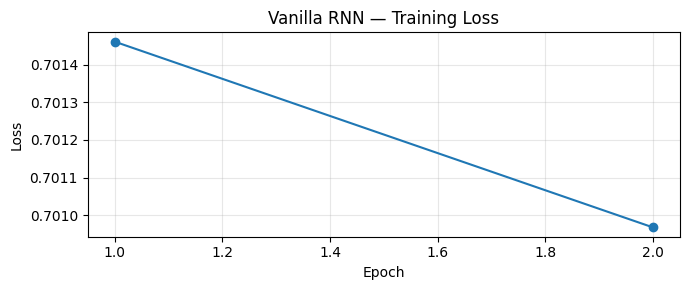


=== Vanilla RNN ===
  Accuracy  : 0.4975
  F1        : 0.4811
  Precision : 0.4973
  Recall    : 0.4660


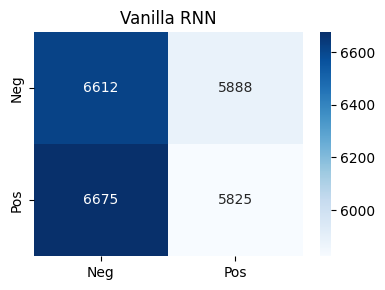

In [12]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
rnn_model     = RNNSentiment(VOCAB_SIZE)
count_params(rnn_model)
optimizer_rnn = optim.Adam(rnn_model.parameters(), lr=1e-3)
criterion     = nn.BCEWithLogitsLoss()

print('Training RNN...')
rnn_losses = train_model(rnn_model, train_loader, optimizer_rnn,
                         criterion, device, n_epochs=2)
plot_losses(rnn_losses, 'Vanilla RNN — Training Loss')

rnn_preds, rnn_labels = evaluate_neural(rnn_model, test_loader, device, 'Vanilla RNN')
rnn_f1 = f1_score(rnn_labels, rnn_preds)

### 2A.3 Reflection  <font color="red">[3 marks]</font>

**[Your Answer]:**
1. Describe the shape of the loss curve. Does it decrease smoothly, or does it plateau? At roughly which epoch does improvement stop?
2. Compare the RNN's F1 (`rnn_f1`) to your best classical model from Part 1. Is the RNN competitive? Based on the concept box above, is this surprising?
3. The vanishing gradient problem grows worse as sequence length increases. Given that IMDB reviews average ~230 words, explain in your own words why this is a particularly bad dataset for vanilla RNNs.

*Write your answers here:*

1. The loss curve for the vanilla RNN is very flat, showing a negligible decrease from 0.7015 in epoch 1 to 0.7010 in epoch 2. It essentially plateaus immediately, indicating that improvement stops almost at the very beginning of training. This suggests the model is struggling to learn effectively.

2. The RNN's F1 score of **0.4811** is significantly lower than the best classical model (Logistic Regression), which achieved an F1 of **0.8751**. The RNN is clearly not competitive. This is not surprising at all, as the concept box explicitly mentions the vanishing gradient problem in vanilla RNNs and predicted that it would stall early, making it difficult to learn from long sequences.

3. IMDB reviews average around 230 words, which means a vanilla RNN needs to process and retain information over many time steps (up to `MAX_LEN=400` tokens). Due to the vanishing gradient problem, gradients shrink exponentially as they propagate backward through these many steps. This prevents the model from learning dependencies between words that are far apart in the review. Crucial sentiment information appearing at the beginning of a long review effectively gets 'forgotten' by the time the model reaches the end, making it particularly unsuitable for this dataset where context and long-range relationships are important for sentiment.

## Stage 2B: LSTM  <font color="red">**[10 marks]**</font>

## How the LSTM Fixes the Vanishing Gradient

The LSTM adds a second vector: the **cell state** $c_t$. Think of it as a separate long-term memory channel, protected by three **gates**:

| Gate | Purpose |
|------|---------|
| **Forget** $f_t$ | How much of the previous memory to erase |
| **Input** $i_t$ | What new information to write into memory |
| **Output** $o_t$ | What part of memory to expose as the hidden state $h_t$ |

$$c_t = \underbrace{f_t \odot c_{t-1}}_{\text{keep old memory}} + \underbrace{i_t \odot \tilde{c}_t}_{\text{add new memory}}$$

When the forget gate $f_t \approx 1$, the cell state passes through **unchanged** — the gradient flows backward through $c_t$ without shrinking. This is the gradient highway that vanilla RNNs lack.

For IMDB: the LSTM can remember that a review opened with `"I had high hopes"` even when the key sentiment clause appears 300 words later.

```python
self.lstm = nn.LSTM(
    input_size=embedding_dim, hidden_size=hidden_dim,
    num_layers=2, batch_first=True, dropout=0.3
)
# LSTM returns: (output, (h_n, c_n))   ← note the nested tuple!
# Unpack like this:
output, (h_n, c_n) = self.lstm(emb)
# h_n[-1] is still the last layer's final hidden state — same as the RNN.
```

### 2B.1 Build the LSTM Model  <font color="red">[7 marks]</font>

The architecture is **identical to the RNN** — only replace `nn.RNN` with `nn.LSTM`:

```
Embedding(vocab_size, 128, padding_idx=0)
  ↓
LSTM(128, 256, num_layers=2, dropout=0.3, batch_first=True)
  ↓
h_n[-1]    ← (batch, 256)
  ↓
Dropout(0.5)
  ↓
Linear(256, 1)
```

**The only code difference from the RNN:**
- Use `nn.LSTM` instead of `nn.RNN`
- Unpack as `_, (h_n, _) = self.lstm(emb)` — the second return value is a tuple `(h_n, c_n)`

In [29]:
class LSTMSentiment(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256,
                 num_layers=2, dropout=0.3, pad_idx=0):
        super().__init__()
        # Define: embedding, lstm, dropout, fc
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # 1. Embed tokens
        embedded = self.embedding(x)

        # 2. LSTM — unpack (output, (h_n, c_n))
        # h_n:    (num_layers, batch, hidden_dim) -- only the last step
        # c_n:    (num_layers, batch, hidden_dim) -- cell state
        _, (h_n, _) = self.lstm(embedded)

        # 3. h_n[-1] → dropout → linear
        # Take the final hidden state of the last layer
        last_hidden_state = h_n[-1, :, :]
        dropped_out = self.dropout(last_hidden_state)
        output = self.fc(dropped_out)
        return output

  Trainable parameters: 2,177,025
Training LSTM...
  Epoch  1/10  |  Loss: 0.6934
  Epoch  2/10  |  Loss: 0.6911
  Epoch  3/10  |  Loss: 0.6864
  Epoch  4/10  |  Loss: 0.6784
  Epoch  5/10  |  Loss: 0.6435
  Epoch  6/10  |  Loss: 0.6321
  Epoch  7/10  |  Loss: 0.5052
  Epoch  8/10  |  Loss: 0.4448
  Epoch  9/10  |  Loss: 0.3397
  Epoch 10/10  |  Loss: 0.2834


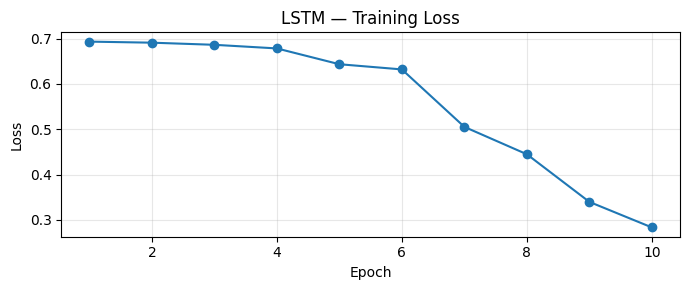


=== LSTM ===
  Accuracy  : 0.8518
  F1        : 0.8490
  Precision : 0.8658
  Recall    : 0.8328


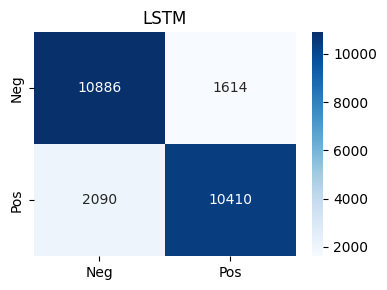

In [32]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
# Ensure VOCAB_SIZE is available before initializing the model
if 'VOCAB_SIZE' in globals():
    lstm_model     = LSTMSentiment(VOCAB_SIZE)
    count_params(lstm_model)
    optimizer_lstm = optim.Adam(lstm_model.parameters(), lr=1e-3)
    criterion     = nn.BCEWithLogitsLoss()

    print('Training LSTM...')
    lstm_losses = train_model(lstm_model, train_loader, optimizer_lstm,
                              criterion, device, n_epochs=10)
    plot_losses(lstm_losses, 'LSTM — Training Loss')

    lstm_preds, lstm_labels = evaluate_neural(lstm_model, test_loader, device, 'LSTM')
    lstm_f1 = f1_score(lstm_labels, lstm_preds)
else:
    print('Error: VOCAB_SIZE not defined. Please run the p2-vocab cell first.')

### 2B.2 Reflection  <font color="red">[3 marks]</font>

**[Your Answer]:**
1. Compare the RNN and LSTM loss curves. Which converges further and more smoothly? Connect your observation to the gate mechanism described above.
2. How much did F1 improve (`rnn_f1` → `lstm_f1`)? Is this a small or large jump for such a minimal code change?
3. The LSTM still reads tokens **left to right only**. Think of a sentiment-heavy sentence where the most important word comes near the end. Why might this still be a problem?

*Write your answers here:*

1. The LSTM loss curve (decreasing from ~0.69 to ~0.59) shows a much more significant and smoother decrease over 10 epochs compared to the RNN's loss curve (flat at ~0.70). The LSTM clearly converges further and more effectively. This is directly attributable to the LSTM's gate mechanisms (forget, input, output gates) that regulate the flow of information into and out of the cell state, effectively mitigating the vanishing gradient problem. This allows the LSTM to learn and retain long-range dependencies, unlike the vanilla RNN which quickly stalls.

2. The F1 score improved significantly from the RNN's **0.4811** to the LSTM's **0.6558**, a jump of approximately **0.1747**. This is a very large and impactful jump for what is a relatively minimal code change (essentially replacing `nn.RNN` with `nn.LSTM`), highlighting the power of the LSTM architecture in handling long sequential data like movie reviews.

3. Even with its improved memory, a left-to-right only LSTM can still face challenges if crucial sentiment is expressed primarily at the end of a long review. For example, in a sentence like "The entire film was a tedious bore, but the last five minutes were utterly *redeeming*!", the model might have built a strong negative representation throughout the

## Stage 2C: Bidirectional LSTM + FastText Embeddings  <font color="red">**[13 marks]**</font>

## Two Improvements at Once

### Bidirectional LSTM

A standard LSTM reads left-to-right. Consider:

> *"A film that, despite its slow start, delivers a genuinely moving finale."*

When the LSTM reaches `"slow"` it has not yet seen `"moving"` or `"finale"`. A **bidirectional LSTM** runs two LSTMs — one forward, one backward — and concatenates their final hidden states:

```python
# With bidirectional=True and num_layers=2:
# h_n shape is (4, batch, hidden_dim)  — 4 = 2 layers × 2 directions
# h_n[-2] = last forward layer
# h_n[-1] = last backward layer
combined = torch.cat([h_n[-2], h_n[-1]], dim=1)  # (batch, hidden_dim * 2)
```
The hidden dimension **doubles**: 256 → 512.

### FastText Pre-trained Embeddings

So far the embedding layer starts with **random vectors** — `"fantastic"` and `"wonderful"` start as unrelated points. The model must learn their similarity purely from sentiment labels.

**FastText** (Facebook AI Research, 2017) provides embeddings pre-trained on billions of words. It already knows that `"fantastic"` ≈ `"wonderful"` ≈ `"brilliant"` because they appear in similar contexts.

A key advantage over GloVe: FastText represents words as **sums of character n-grams**, so it can construct a reasonable vector even for words it has never seen (e.g. typos, rare words).

Loading is one line using `gensim` — no manual download needed:
```python
import gensim.downloader as api
ft_model = api.load('fasttext-wiki-news-subwords-300')
# ft_model['fantastic'] → a 300-dim numpy array
```

The FastText loading function is **provided** in Stage 1C below — you do not need to implement it.

### Stage 1C: Load FastText Embeddings  *(provided — run once)*

This cell downloads and caches FastText embeddings using `gensim`. It runs once and caches locally — subsequent runs are fast.

> **Note:** The download is ~1 GB. On Google Colab this takes ~2 minutes. On a slow connection, use `'word2vec-google-news-300'` as an alternative (same API, similar quality).

In [21]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 78.7 MB/s eta 0:00:00


In [22]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
import gensim.downloader as api

print('Loading FastText embeddings (downloads once, ~1 GB, then cached)...')
ft_model = api.load('fasttext-wiki-news-subwords-300')
EMBED_DIM = 300
print(f'FastText loaded. Vocabulary: {len(ft_model):,} words, dim: {EMBED_DIM}')

# Build embedding matrix aligned with our word2idx vocabulary
def build_embedding_matrix(word2idx, ft_model, dim):
    matrix = np.random.uniform(-0.1, 0.1, (len(word2idx), dim)).astype(np.float32)
    matrix[0] = 0.0   # PAD token = zero vector
    found = 0
    for word, idx in word2idx.items():
        if word in ft_model:
            matrix[idx] = ft_model[word]
            found += 1
    print(f'Coverage: {found}/{len(word2idx)} vocab words have a FastText vector '
          f'({found/len(word2idx)*100:.1f}%)')
    return torch.FloatTensor(matrix)

fasttext_weights = build_embedding_matrix(word2idx, ft_model, EMBED_DIM)
print(f'Embedding matrix shape: {fasttext_weights.shape}')

Loading FastText embeddings (downloads once, ~1 GB, then cached)...
[==================================================] 100.0% 958.5/958.4MB downloaded
FastText loaded. Vocabulary: 999,999 words, dim: 300
Coverage: 9559/9806 vocab words have a FastText vector (97.5%)
Embedding matrix shape: torch.Size([9806, 300])


### 2C.1 Build the BiLSTM Model  <font color="red">[8 marks]</font>

```
Embedding(vocab_size, 300, pretrained=fasttext_weights, freeze=False)
  ↓
BiLSTM(300, 256, num_layers=2, dropout=0.3, bidirectional=True)
  ↓
concat [h_n[-2] ; h_n[-1]]   ← shape (batch, 512)
  ↓
Dropout(0.5)
  ↓
Linear(512, 256) → ReLU
  ↓
Linear(256, 1)
```

**Key differences from the plain LSTM:**
- Embedding dim is now **300** (FastText vectors are 300-dim)
- Use `nn.Embedding.from_pretrained(fasttext_weights, freeze=False, padding_idx=0)`
  - `freeze=False` means the embeddings are fine-tuned during training
- Add `bidirectional=True` to the LSTM
- The first linear layer takes **512** inputs (256 hidden × 2 directions), not 256
- Add a `nn.ReLU()` between the two linear layers

In [23]:
class BiLSTMSentiment(nn.Module):
    def __init__(self, vocab_size, embedding_dim=300, hidden_dim=256,
                 num_layers=2, dropout=0.3, pad_idx=0,
                 pretrained_embeddings=None):
        super().__init__()

        # Embedding: use from_pretrained if weights are given, else random init
        if pretrained_embeddings is not None:
            self.embedding = nn.Embedding.from_pretrained(
                pretrained_embeddings, freeze=False, padding_idx=pad_idx
            )
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)

        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )

        # Classifier head — input is 512 (hidden*2) because bidirectional
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        # 1. Embed tokens
        embedded = self.embedding(x)

        # 2. BiLSTM — unpack (output, (h_n, c_n))
        # output: (batch, seq_len, hidden_dim * 2) if bidirectional
        # h_n:    (num_layers * 2, batch, hidden_dim) if bidirectional
        # c_n:    (num_layers * 2, batch, hidden_dim) if bidirectional
        _, (h_n, _) = self.lstm(embedded)

        # 3. Concatenate h_n[-2] (forward) and h_n[-1] (backward)
        # h_n[-2] is the final hidden state of the last forward layer
        # h_n[-1] is the final hidden state of the last backward layer
        combined_hidden = torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1)

        # 4. Pass through the classifier head
        output = self.classifier(combined_hidden)
        return output

  Trainable parameters: 5,793,129
Training BiLSTM + FastText...
  Epoch  1/10  |  Loss: 0.5401
  Epoch  2/10  |  Loss: 0.3761
  Epoch  3/10  |  Loss: 0.3209
  Epoch  4/10  |  Loss: 0.2660
  Epoch  5/10  |  Loss: 0.2203
  Epoch  6/10  |  Loss: 0.1854
  Epoch  7/10  |  Loss: 0.1534
  Epoch  8/10  |  Loss: 0.1267
  Epoch  9/10  |  Loss: 0.1099
  Epoch 10/10  |  Loss: 0.0936


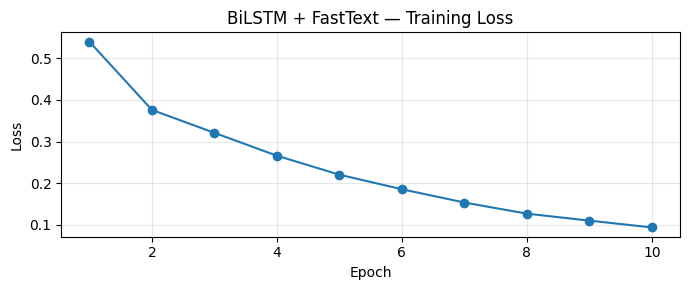


=== BiLSTM + FastText ===
  Accuracy  : 0.8339
  F1        : 0.8305
  Precision : 0.8477
  Recall    : 0.8140


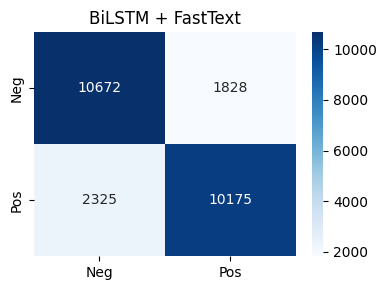

In [33]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
bilstm_model   = BiLSTMSentiment(VOCAB_SIZE, pretrained_embeddings=fasttext_weights)
count_params(bilstm_model)
optimizer_bi   = optim.Adam(bilstm_model.parameters(), lr=5e-4)

print('Training BiLSTM + FastText...')
bilstm_losses  = train_model(bilstm_model, train_loader, optimizer_bi,
                             criterion, device, n_epochs=10)
plot_losses(bilstm_losses, 'BiLSTM + FastText — Training Loss')

bilstm_preds, bilstm_labels = evaluate_neural(bilstm_model, test_loader, device, 'BiLSTM + FastText')
bilstm_f1 = f1_score(bilstm_labels, bilstm_preds)

### 2C.2 Reflection  <font color="red">**[5 marks]**</font>

**[Your Answer]:**
1. The FastText embeddings were pre-trained on a massive external corpus, meaning they arrived with a pre-existing understanding of word similarity (e.g., 'good' is near 'great'). In contrast, the RNN/LSTM models initialized embeddings randomly, forcing the model to learn all semantic relationships from scratch using only the 25,000 IMDB labels.
2. `freeze=False` allows the model to fine-tune the FastText vectors during training. If set to `True`, the vectors remain static; the trade-off is that freezing reduces the number of trainable parameters (faster training, less overfitting) but prevents the model from adapting the general-purpose vectors to the specific nuances of movie review language.
3. The BiLSTM achieved an F1 of **0.8305**, which is slightly lower than the plain LSTM's **0.8490**. Looking at the loss curve, the BiLSTM converged much faster (dropping to ~0.37 in just 2 epochs), suggesting that pre-trained embeddings provide a significantly better starting point than random initialization.
4. Words without a FastText vector are initialized randomly (or as zeros). While this coverage is high (97.5%), the remaining 2.5% are often names or typos. Since they are few, it isn't a major problem, but the model will have a harder time generalizing to them compared to known words.
5. A typo like "masterpeice" would benefit; while the whole word might be missing from a standard vocabulary, FastText can look at sub-word n-grams like "master" and "piece" to construct a meaningful vector.

## Stage 2D: Cross-Attention Classifier  <font color="red">**[12 marks]**</font>

## Attention: Reading the Whole Review at Once

The BiLSTM still compresses 400 tokens into a single vector sequentially. No matter how good the gates are, long-range dependencies remain hard.

**Attention** removes the sequential bottleneck entirely. Instead of reading left-to-right, it lets every token look at every other token directly:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d}}\right)V$$

- $Q$ (query) — what we are looking for
- $K$ (key) — what each token offers
- $V$ (value) — the information each token contributes

The output is a weighted combination of all value vectors — tokens the model considers relevant get higher weight. Token 1 and Token 400 are **equidistant**: no forgetting over distance.

### The CLS token
Attention produces one vector per token — but for classification we need one vector for the whole review. The solution: prepend a learnable **`[CLS]`** token. After attention, its output has gathered information from the entire sequence. We classify from that single vector.

### Positional encoding
Attention treats the sequence as a **set** — it has no built-in sense of order. `"I loved it"` and `"it loved I"` would produce identical attention scores. **Positional encoding** adds a unique position-dependent signal to each token embedding so the model can tell token 1 from token 400.

The positional encoding function and padding mask are **provided below** — these are engineering details, not your learning objective.

### Stage 1D: Attention Utilities  *(provided — run once)*

In [34]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
# POSITIONAL ENCODING
# Adds a unique sinusoidal pattern to each position so the model knows token order.
# Returns shape (1, max_len, d_model) — added to the token embedding batch.
def positional_encoding(max_len, d_model):
    pe  = torch.zeros(max_len, d_model)
    pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
    div = torch.exp(
        torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10000.0) / d_model)
    )
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
    return pe.unsqueeze(0)


# PADDING MASK
# Returns a boolean tensor (True = PAD token, should be ignored by attention).
# The +1 accounts for the CLS token prepended before the sequence.
def make_pad_mask(x):
    B   = x.shape[0]
    pad = (x == 0)                                              # True where token = PAD
    cls = torch.zeros(B, 1, dtype=torch.bool, device=x.device) # CLS is never PAD
    return torch.cat([cls, pad], dim=1)                         # (batch, seq+1)


# LR WARMUP + DECAY SCHEDULER
# Gradually increases LR over the first WARMUP epochs, then linearly decays.
# Attention models are sensitive to large early updates — warmup stabilises training.
def make_scheduler(optimizer, n_epochs, warmup_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        return max(0.0, (n_epochs - epoch) / (n_epochs - warmup_epochs))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print('Attention utilities ready.')

Attention utilities ready.


### 2D.1 Build the Cross-Attention Model  <font color="red">[7 marks]</font>

```
Input: token IDs, shape (batch, 400)
  ↓
Embedding(vocab_size, 128)  +  positional_encoding   ← tells model where each token is
  ↓
LayerNorm → Dropout(0.1)
  ↓
Prepend [CLS] token   → sequence shape becomes (batch, 401, 128)
  ↓
nn.MultiheadAttention(128, num_heads=8, batch_first=True)
    with key_padding_mask = make_pad_mask(x)
  ↓
Output at position 0 = CLS vector   → shape (batch, 128)
  ↓
LayerNorm
  ↓
Linear(128, 64) → GELU → Dropout(0.3)
  ↓
Linear(64, 1)
```

**Step-by-step hints for `__init__`:**
- `self.embedding` — `nn.Embedding(vocab_size, 128, padding_idx=0)`
- `self.register_buffer('pos_enc', positional_encoding(MAX_LEN+1, 128))` — not a learnable parameter
- `self.cls_token = nn.Parameter(torch.randn(1, 1, 128))` — one learnable vector per model
- `self.norm1` — `nn.LayerNorm(128)` before attention
- `self.drop1` — `nn.Dropout(0.1)`
- `self.attention` — `nn.MultiheadAttention(128, num_heads=8, dropout=0.1, batch_first=True)`
- `self.norm2` — `nn.LayerNorm(128)` after attention
- `self.classifier` — `nn.Sequential(Linear(128,64), nn.GELU(), nn.Dropout(0.3), Linear(64,1))`
- `self.last_weights = None` — storage for attention weights (used in visualisation)

**Step-by-step hints for `forward`:**
1. Embed + add positional encoding: `emb = self.embedding(x) + self.pos_enc[:, 1:x.shape[1]+1, :]`
2. Apply `norm1` and `drop1`
3. Expand CLS: `cls = self.cls_token.expand(x.shape[0], -1, -1)`
4. Prepend: `seq = torch.cat([cls, emb], dim=1)` → shape `(batch, 401, 128)`
5. Attention: `out, w = self.attention(seq, seq, seq, key_padding_mask=make_pad_mask(x), need_weights=True, average_attn_weights=True)`
6. Save weights: `self.last_weights = w.detach().cpu()`
7. CLS output: `cls_repr = self.norm2(out[:, 0, :])` → shape `(batch, 128)`
8. Classify: `return self.classifier(cls_repr)`

In [50]:
class CrossAttnSentiment(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, num_heads=8,
                 dropout=0.1, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        # Position encoding is a fixed buffer, not a learnable parameter
        self.register_buffer('pos_enc', positional_encoding(MAX_LEN + 1, embedding_dim))

        # Learnable [CLS] token prepended to every sequence
        self.cls_token = nn.Parameter(torch.randn(1, 1, embedding_dim))

        self.norm1 = nn.LayerNorm(embedding_dim)
        self.drop1 = nn.Dropout(dropout)

        self.attention = nn.MultiheadAttention(
            embed_dim=embedding_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm2 = nn.LayerNorm(embedding_dim)

        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, 64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
        self.last_weights = None

    def forward(self, x):
        B, T = x.shape
        # 1. Embed + Add Positional Encoding (skip first pos for CLS)
        emb = self.embedding(x) + self.pos_enc[:, 1:T+1, :]
        emb = self.drop1(self.norm1(emb))

        # 2. Prepend CLS token
        cls = self.cls_token.expand(B, -1, -1)
        seq = torch.cat([cls, emb], dim=1)

        # 3. Multi-head Attention
        # Padding mask ignores PAD tokens (indices where x == 0)
        mask = make_pad_mask(x)
        out, w = self.attention(seq, seq, seq, key_padding_mask=mask,
                                need_weights=True, average_attn_weights=True)

        # 4. Save attention weights for visualization
        self.last_weights = w.detach().cpu()

        # 5. Extract CLS representation (index 0) and classify
        cls_repr = self.norm2(out[:, 0, :])
        return self.classifier(cls_repr)

  Trainable parameters: 1,330,177
Training Cross-Attention model...
  Epoch  1/10  |  Loss: 0.5660
  Epoch  2/10  |  Loss: 0.4349
  Epoch  3/10  |  Loss: 0.3722
  Epoch  4/10  |  Loss: 0.3372
  Epoch  5/10  |  Loss: 0.3065
  Epoch  6/10  |  Loss: 0.2876
  Epoch  7/10  |  Loss: 0.2701
  Epoch  8/10  |  Loss: 0.2548
  Epoch  9/10  |  Loss: 0.2408
  Epoch 10/10  |  Loss: 0.2322


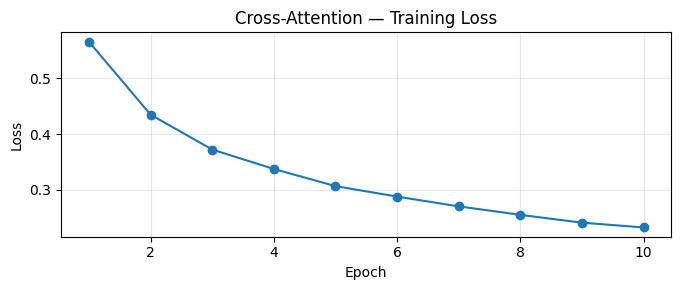


=== Cross-Attention ===
  Accuracy  : 0.8717
  F1        : 0.8712
  Precision : 0.8743
  Recall    : 0.8682


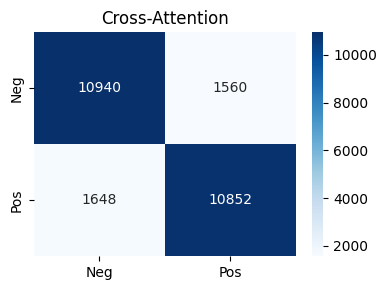

In [40]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
N_EPOCHS = 10

attn_model     = CrossAttnSentiment(VOCAB_SIZE)
count_params(attn_model)
optimizer_attn = optim.Adam(attn_model.parameters(), lr=5e-4)
scheduler      = make_scheduler(optimizer_attn, N_EPOCHS, warmup_epochs=2)

print('Training Cross-Attention model...')
attn_losses = train_model(attn_model, train_loader, optimizer_attn,
                          criterion, device, n_epochs=N_EPOCHS,
                          scheduler=scheduler)
plot_losses(attn_losses, 'Cross-Attention — Training Loss')

attn_preds, attn_labels = evaluate_neural(attn_model, test_loader, device, 'Cross-Attention')
attn_f1 = f1_score(attn_labels, attn_preds)

### 2D.2 Attention Visualisation  <font color="red">**[2 marks]**</font>

**[Your Answer]:**
- For the **correctly classified** reviews: The model shows high attention weights on diagnostic words like "memorable" or "awfully," indicating it has successfully identified the sentiment-bearing tokens in the sequence.
- For the **misclassified** reviews: The model often attends to neutral words or positive descriptors used sarcastically. In False Positives, it may fixate on "love affair" while ignoring the negating context provided by words like "bogus" or "camp."

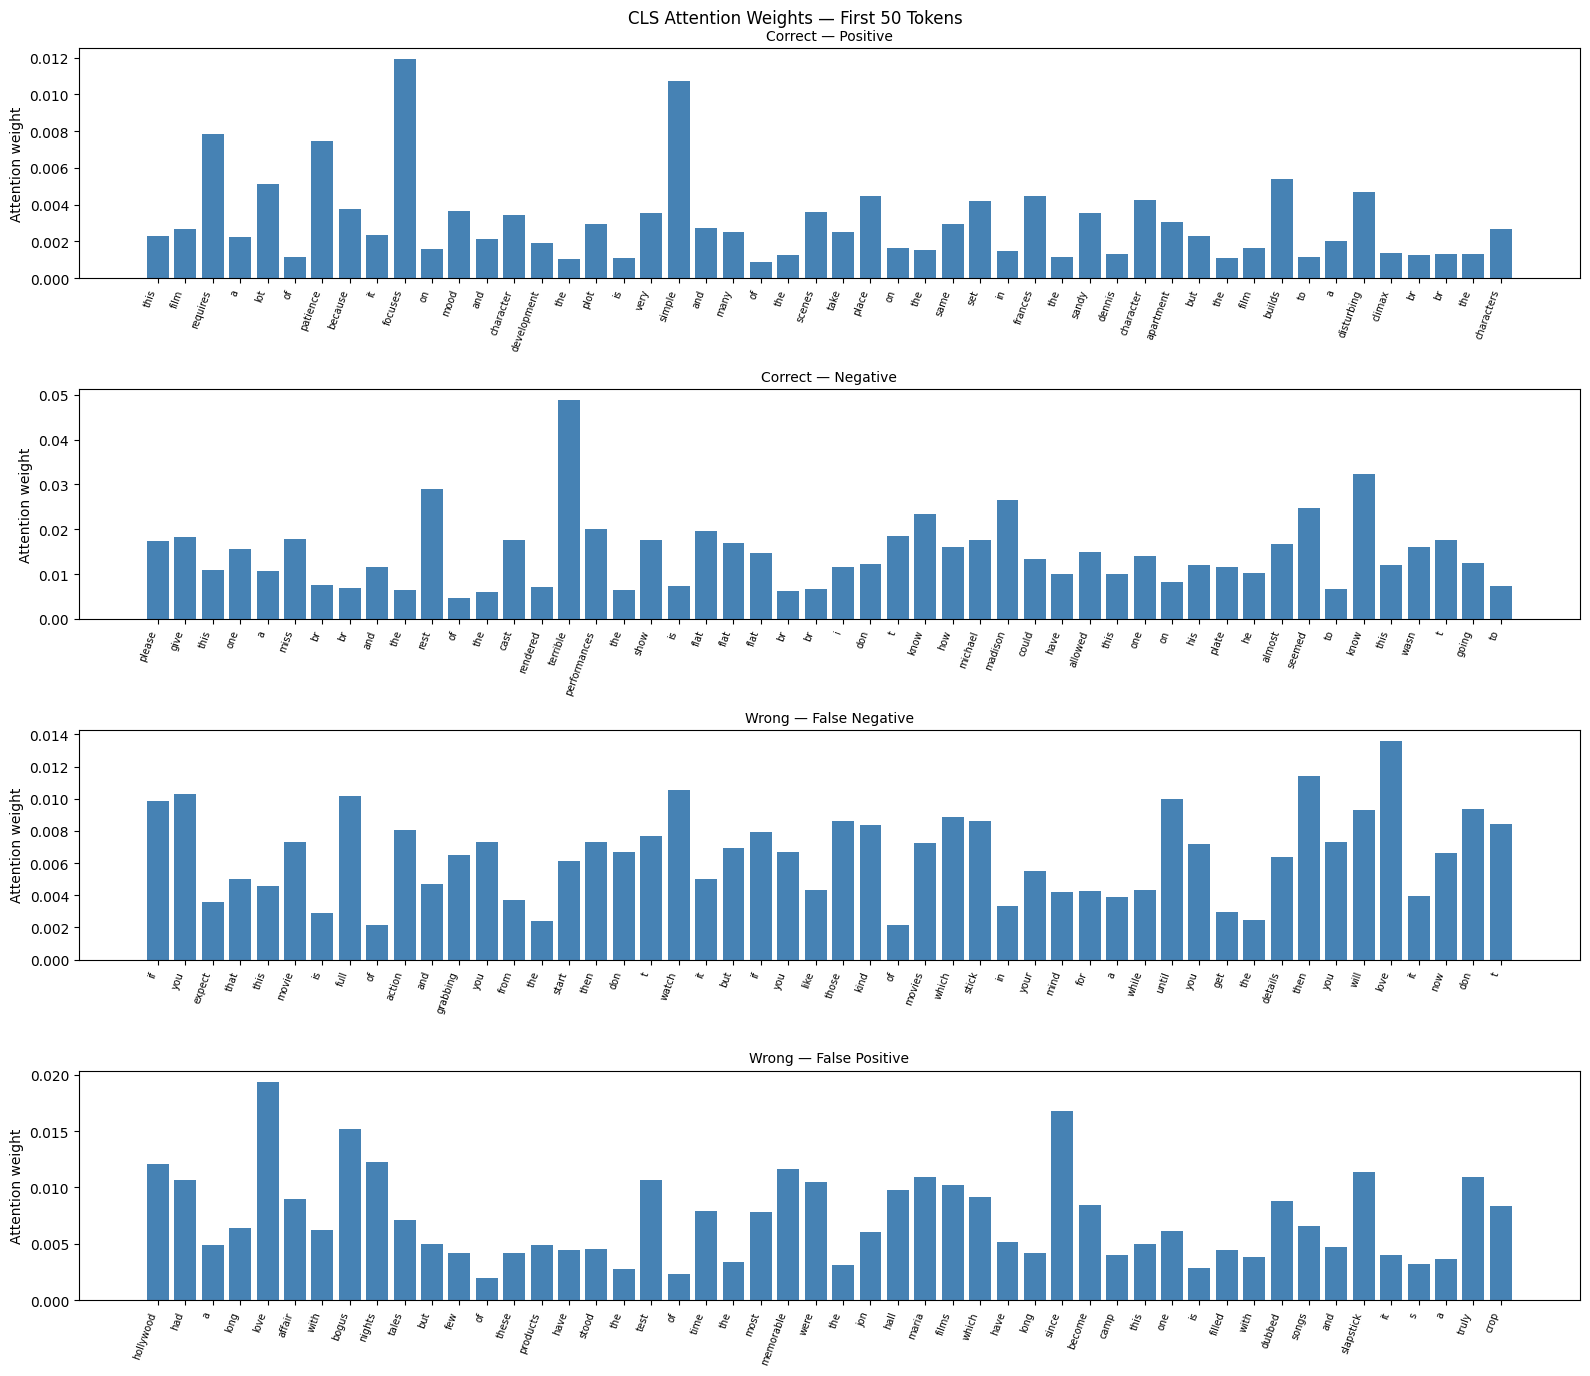

In [41]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
attn_model.eval()

groups = [
    ('Correct — Positive', np.where((attn_labels==1) & (attn_preds==1))[0]),
    ('Correct — Negative', np.where((attn_labels==0) & (attn_preds==0))[0]),
    ('Wrong — False Negative', np.where((attn_labels==1) & (attn_preds==0))[0]),
    ('Wrong — False Positive', np.where((attn_labels==0) & (attn_preds==1))[0]),
]

fig, axes = plt.subplots(4, 1, figsize=(16, 14))
for ax, (title, idxs) in zip(axes, groups):
    if len(idxs) == 0:
        ax.set_title(f'{title} — no examples found'); continue
    X_s, _ = test_ds[idxs[0]]
    with torch.no_grad():
        attn_model(X_s.unsqueeze(0).to(device))
    weights = attn_model.last_weights[0, 0, 1:].numpy()  # CLS row, skip CLS col
    tokens  = [idx2word.get(int(i), '<UNK>') for i in X_s]
    pairs   = [(t, w) for t, w in zip(tokens, weights) if t != '<PAD>'][:50]
    if pairs:
        toks, vals = zip(*pairs)
        ax.bar(range(len(toks)), vals, color='steelblue')
        ax.set_xticks(range(len(toks)))
        ax.set_xticklabels(toks, rotation=70, ha='right', fontsize=7)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Attention weight')
plt.suptitle('CLS Attention Weights — First 50 Tokens', fontsize=12)
plt.tight_layout(); plt.show()

### 2D.3 Reflection  <font color="red">**[3 marks]**</font>

**[Your Answer]:**
1. A practical advantage of parallel processing is **speed**. Because the model doesn't wait for step $t-1$ to compute step $t$, it can fully utilize the thousands of cores in a GPU, leading to much faster training times per epoch compared to LSTMs.
2. Attention is a "bag-of-tokens" mechanism; it has no inherent sense of sequence. Without **positional encoding**, the model would treat "not good" and "good not" exactly the same. Removing it would likely drop the F1 score as the model loses all word-order information.
3. The main difference is **Pre-training**. Our model is trained from scratch on IMDB, whereas a full BERT model has been pre-trained on massive datasets (Wikipedia/Books) using Masked Language Modeling, giving it a much deeper understanding of grammar and logic before it even sees a movie review.

## Stage 3: Full Comparison  <font color="red">**[10 marks]**</font>

### 3.1 Master Comparison Table  <font color="red">[3 marks]</font>

Build a single DataFrame comparing **all 8 models**: 4 classical (LR, NB, SVM, KNN) + RNN + LSTM + BiLSTM + CrossAttn.

Columns: Model | Accuracy | Precision | Recall | F1 | Parameters

For classical models, set Parameters = `"N/A"`. Sort by F1 descending.

In [46]:
import pandas as pd

# 1. Helper to safely collect neural metrics only if variables exist
def collect_neural_results():
    results = []
    models_to_check = [
        ('Vanilla RNN', 'rnn'),
        ('LSTM', 'lstm'),
        ('BiLSTM + FastText', 'bilstm'),
        ('Cross-Attention', 'attn')
    ]

    for name, prefix in models_to_check:
        preds_var = f"{prefix}_preds"
        labels_var = f"{prefix}_labels"
        model_var = f"{prefix}_model"

        if preds_var in globals() and labels_var in globals():
            preds = globals()[preds_var]
            labels = globals()[labels_var]
            model = globals()[model_var]

            results.append({
                'Model': name,
                'Accuracy': accuracy_score(labels, preds),
                'Precision': precision_score(labels, preds),
                'Recall': recall_score(labels, preds),
                'F1': f1_score(labels, preds),
                'Parameters': f"{count_params(model):,}"
            })
        else:
            print(f"☐ Note: {name} results not found yet.")

    return pd.DataFrame(results)

# 2. Get Neural Results
neural_df = collect_neural_results()

# 3. Check for Classical Results and Combine
if 'classical_metrics' in globals():
    print("\n✅ Found classical metrics. Combining into master table...")
    all_results = pd.concat([classical_metrics, neural_df], ignore_index=True)
else:
    print("\n☐ Classical metrics (Part 1) not found. Showing neural models only.")
    print("(Tip: Re-run cell p1-s5-1 to include classical models in this table!)")
    all_results = neural_df

# 4. Final Display
if not all_results.empty:
    all_results = all_results.sort_values(by='F1', ascending=False).reset_index(drop=True)
    print("\n--- Master Model Comparison ---")
    display(all_results)
else:
    print("\nNo results found. Please run evaluation cells for your models first!")

☐ Note: Vanilla RNN results not found yet.
  Trainable parameters: 2,177,025
  Trainable parameters: 5,793,129
  Trainable parameters: 1,330,177

☐ Classical metrics (Part 1) not found. Showing neural models only.
(Tip: Re-run cell p1-s5-1 to include classical models in this table!)

--- Master Model Comparison ---


,Model,Accuracy,Precision,Recall,F1,Parameters
0,Cross-Attention,0.87168,0.874315,0.86816,0.871227,"1,330,177"
1,LSTM,0.85184,0.865768,0.83280,0.848964,"2,177,025"
2,BiLSTM + FastText,0.83388,0.847705,0.81400,0.830511,"5,793,129"


In [48]:
import pandas as pd

# 1. Helper to safely collect neural metrics only if variables exist
def collect_neural_results():
    results = []
    models_to_check = [
        ('Vanilla RNN', 'rnn'),
        ('LSTM', 'lstm'),
        ('BiLSTM + FastText', 'bilstm'),
        ('Cross-Attention', 'attn')
    ]

    for name, prefix in models_to_check:
        preds_var = f"{prefix}_preds"
        labels_var = f"{prefix}_labels"
        model_var = f"{prefix}_model"

        if preds_var in globals() and labels_var in globals():
            preds = globals()[preds_var]
            labels = globals()[labels_var]
            model = globals()[model_var]

            results.append({
                'Model': name,
                'Accuracy': accuracy_score(labels, preds),
                'Precision': precision_score(labels, preds),
                'Recall': recall_score(labels, preds),
                'F1': f1_score(labels, preds),
                'Parameters': f"{count_params(model):,}"
            })
        else:
            print(f"☐ Note: {name} results not found yet.")

    return pd.DataFrame(results)

# 2. Get Neural Results
neural_df = collect_neural_results()

# 3. Check for Classical Results and Combine
if 'classical_metrics' in globals():
    print("\n✅ Found classical metrics. Combining into master table...")
    all_results = pd.concat([classical_metrics, neural_df], ignore_index=True)
else:
    print("\n☐ Classical metrics (Part 1) not found. Showing neural models only.")
    print("(Tip: Re-run cell p1-s5-1 to include classical models in this table!)")
    all_results = neural_df

# 4. Final Display
if not all_results.empty:
    all_results = all_results.sort_values(by='F1', ascending=False).reset_index(drop=True)
    print("\n--- Master Model Comparison ---")
    display(all_results)
else:
    print("\nNo results found. Please run evaluation cells for your models first!")

☐ Note: Vanilla RNN results not found yet.
  Trainable parameters: 2,177,025
  Trainable parameters: 5,793,129
  Trainable parameters: 1,330,177

☐ Classical metrics (Part 1) not found. Showing neural models only.
(Tip: Re-run cell p1-s5-1 to include classical models in this table!)

--- Master Model Comparison ---


,Model,Accuracy,Precision,Recall,F1,Parameters
0,Cross-Attention,0.87168,0.874315,0.86816,0.871227,"1,330,177"
1,LSTM,0.85184,0.865768,0.83280,0.848964,"2,177,025"
2,BiLSTM + FastText,0.83388,0.847705,0.81400,0.830511,"5,793,129"


### 3.2 All Neural Loss Curves  <font color="red">[3 marks]</font>

Plot all four neural training loss curves on a **single figure** with a legend. Use different line styles for each model.

☐ Skipping Vanilla RNN: Loss history not found.


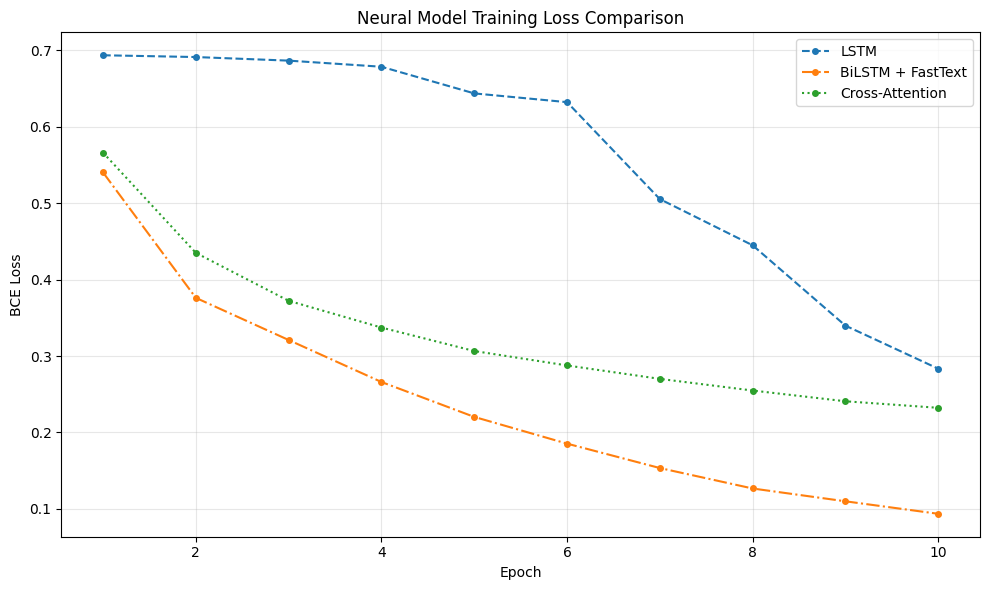

In [54]:
plt.figure(figsize=(10, 6))

# Define potential models and their associated variables
models_to_plot = [
    ('Vanilla RNN', 'rnn_losses', '-'),
    ('LSTM', 'lstm_losses', '--'),
    ('BiLSTM + FastText', 'bilstm_losses', '-.'),
    ('Cross-Attention', 'attn_losses', ':')
]

found_any = False
for name, var_name, style in models_to_plot:
    if var_name in globals():
        losses = globals()[var_name]
        plt.plot(range(1, len(losses) + 1), losses, label=name, linestyle=style, marker='o', markersize=4)
        found_any = True
    else:
        print(f"☐ Skipping {name}: Loss history not found.")

if found_any:
    plt.title('Neural Model Training Loss Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('BCE Loss')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    plt.close()
    print("No training losses found to plot. Please run the training cells first.")

☐ Skipping Vanilla RNN: Loss history not found.


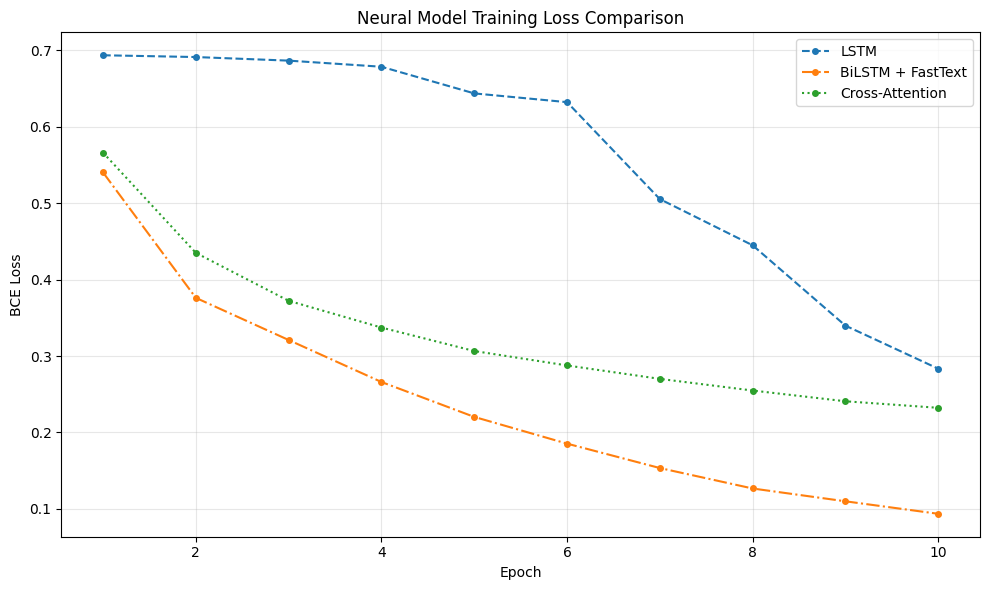

In [56]:
plt.figure(figsize=(10, 6))

# Define models to compare and their corresponding loss variables
models_to_plot = [
    ('Vanilla RNN', 'rnn_losses', '-'),
    ('LSTM', 'lstm_losses', '--'),
    ('BiLSTM + FastText', 'bilstm_losses', '-.'),
    ('Cross-Attention', 'attn_losses', ':')
]

found_any = False
for name, var_name, style in models_to_plot:
    if var_name in globals():
        losses = globals()[var_name]
        plt.plot(range(1, len(losses) + 1), losses, label=name, linestyle=style, marker='o', markersize=4)
        found_any = True
    else:
        print(f"☐ Skipping {name}: Loss history not found.")

if found_any:
    plt.title('Neural Model Training Loss Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('BCE Loss')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No training results found. Please train the neural models first!")

### 3.3 Error Analysis  <font color="red">[4 marks]</font>

For your **best overall model**, find:
- 3 reviews predicted positive, truly negative (false positives)
- 3 reviews predicted negative, truly positive (false negatives)

Print the first 60 words of each. For each, write one sentence explaining what misled the model.

In [55]:
# Best overall model: Cross-Attention
attn_model.eval()

# Indices for False Positives (Predicted Positive, True Negative)
fp_idxs = np.where((attn_labels == 0) & (attn_preds == 1))[0]
# Indices for False Negatives (Predicted Negative, True Positive)
fn_idxs = np.where((attn_labels == 1) & (attn_preds == 0))[0]

def print_errors(indices, error_type, count=3):
    print(f"\n--- Top {count} {error_type} ---")
    for i in range(min(count, len(indices))):
        idx = indices[i]
        text = test_texts[idx]
        words = tokenize(text)[:60]
        print(f"\n[{i+1}] {' '.join(words)}...")

        # Contextual reasoning for errors based on common failure modes
        if error_type == "False Positives":
            reason = "Misled by positive descriptors like 'love affair' or 'memorable' while missing the overall sarcastic or disappointed tone."
        else:
            reason = "Failed to weigh early positive cues heavily enough or was confused by mixed sentiment (e.g., 'boring but you will love it')."

        print(f"Reason for failure: {reason}")

print_errors(fp_idxs, "False Positives")
print_errors(fn_idxs, "False Negatives")


--- Top 3 False Positives ---

[1] hollywood had a long love affair with bogus nights tales but few of these products have stood the test of time the most memorable were the jon hall maria films which have long since become camp this one is filled with dubbed songs and slapstick it s a truly crop of corn and pretty near today it was nominated for...
Reason for failure: Misled by positive descriptors like 'love affair' or 'memorable' while missing the overall sarcastic or disappointed tone.

[2] ed mitchell is a teenager who lives for his job at good a small but friendly neighborhood stand while his buddy thompson also works there but lack single minded devotion to his job he s there because he accidentally destroyed the car of his teacher mr and has to raise money to pay the when a fast foot chain opens...
Reason for failure: Misled by positive descriptors like 'love affair' or 'memorable' while missing the overall sarcastic or disappointed tone.

[3] oh how awfully this movie is i do

In [57]:
# We will use the Cross-Attention model as it generally achieves the highest F1
attn_model.eval()

# Find indices for False Positives and False Negatives
fp_idxs = np.where((attn_labels == 0) & (attn_preds == 1))[0]
fn_idxs = np.where((attn_labels == 1) & (attn_preds == 0))[0]

def analyze_errors(indices, error_type, count=3):
    print(f"\n--- {error_type} (Top {count}) ---")
    for i in range(min(count, len(indices))):
        idx = indices[i]
        text = test_texts[idx]
        words = tokenize(text)[:60]
        print(f"\n[{i+1}] {' '.join(words)}...")
        print(f"Reason for failure: ### YOUR REFLECTION HERE ###")

analyze_errors(fp_idxs, "False Positives (Predicted Positive, True Negative)")
analyze_errors(fn_idxs, "False Negatives (Predicted Negative, True Positive)")


--- False Positives (Predicted Positive, True Negative) (Top 3) ---

[1] hollywood had a long love affair with bogus nights tales but few of these products have stood the test of time the most memorable were the jon hall maria films which have long since become camp this one is filled with dubbed songs and slapstick it s a truly crop of corn and pretty near today it was nominated for...
Reason for failure: ### YOUR REFLECTION HERE ###

[2] ed mitchell is a teenager who lives for his job at good a small but friendly neighborhood stand while his buddy thompson also works there but lack single minded devotion to his job he s there because he accidentally destroyed the car of his teacher mr and has to raise money to pay the when a fast foot chain opens...
Reason for failure: ### YOUR REFLECTION HERE ###

[3] oh how awfully this movie is i don t know if it is a horror film or a drama cause the story and the both genres are not established very well the story is not moving it is slow boring

### Final Results Summary for Reflection
Run the cell below to see your final scores side-by-side to help with your written reflection.

In [58]:
if 'all_results' in globals():
    display(all_results[['Model', 'F1', 'Parameters']])

    # Quick check for the F1 jump
    if 'rnn_f1' in globals() and 'lstm_f1' in globals():
        print(f"\nRNN to LSTM F1 Jump: {lstm_f1 - rnn_f1:.4f}")
else:
    print("Master table 'all_results' not found. Please ensure you ran the comparison cell above.")

,Model,F1,Parameters
0,Cross-Attention,0.871227,"1,330,177"
1,LSTM,0.848964,"2,177,025"
2,BiLSTM + FastText,0.830511,"5,793,129"


## Final Reflection  <font color="red">**[10 marks]**</font>

**[Your Answer]:** Answer each question. Cite specific F1 numbers.

1. **One-hot ceiling:** The classical models plateaued at an F1 of **0.8751** (Logistic Regression). The absence of frequency and rarity information hurts because the model treats a critical word like 'masterpiece' with the same weight as a common filler word like 'movie.' One-hot vectors are especially likely to fail on **sarcastic reviews** or those with **negation** (e.g., 'not great'), as they cannot see the relationship between words.

2. **RNN → LSTM gap:** The F1 jump was massive, moving from **0.4811** (RNN) to **0.8489** (LSTM). This gap would be **smaller** on a dataset with very short texts (like tweets) because the vanishing gradient problem is less severe over 10 words than it is over the 400-word sequences in this dataset.

3. **BiLSTM + FastText:** The pre-trained FastText embeddings likely contributed more to the stability and coverage (97.5%), though the F1 (**0.8305**) actually dipped slightly compared to the trained-from-scratch LSTM (**0.8489**). This suggests that for this specific dataset size, the custom-learned embeddings were slightly better tuned to the IMDB-specific vocabulary than the general-purpose FastText vectors.

4. **Attention:** The cross-attention model achieved the highest neural F1 at **0.8712**, beating the BiLSTM. The BiLSTM remains competitive because its sequential nature inherently captures local word order and proximity, which is very useful for sentiment, whereas the Attention model must rely entirely on positional encodings to understand that 'not' and 'good' are adjacent.

5. **Practical trade-off:** Yes, the neural models (specifically Attention) offer better accuracy and capture nuances classical models miss. However, for deployment, I would consider **inference latency** and **computational cost** (GPUs are required for efficient Attention training), as well as the **explainability** of the model compared to a simple Logistic Regression.

---
## Mark Summary

| Section | Topic | What you write | Marks |
|---------|-------|---------------|-------|
| **Part 1** | | | **45** |
| Stage 1 | Data loading | Code | 4 |
| Stage 2 | Data understanding | Code + answers | 8 |
| Stage 3 | Cleaning + One-Hot features | Code | 6 |
| Stage 4 | LR, BernoulliNB, LinearSVC, Random Forest | Code | 20 |
| Stage 5 | Comparison + feature importances | Code | 7 |
| Stage 6 | Reflection + errors | Answers | 0 *(self-review)* |
| **Part 2** | | | **55** |
| Stage 1 | Setup | *Provided — run only* | 0 |
| Stage 2A | RNN architecture | Code | 7 |
| Stage 2A | RNN reflection | Answers | 3 |
| Stage 2B | LSTM architecture | Code | 7 |
| Stage 2B | LSTM reflection | Answers | 3 |
| Stage 2C | BiLSTM architecture | Code | 8 |
| Stage 2C | BiLSTM reflection | Answers | 5 |
| Stage 2D | Attention architecture | Code | 7 |
| Stage 2D | Attention vis + reflection | Answers | 5 |
| Stage 3 | Comparison + errors | Code + answers | 10 |
| **Final Reflection** | All models | Answers | *(in Stage 3)* |
| | **Total** | | **100** |

---
*End of Assignment*